In [115]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt  
import seaborn as sns  

# Ignore all warnings:
import warnings
warnings.filterwarnings("ignore")

In [116]:
data = pd.read_csv("mushrooms.csv")  
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [117]:
data.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [118]:
M_cols = data.columns.to_list()
print("Value Distribution:\n")
for col in M_cols:
    print(col,"\n",data[col].value_counts(),"\n\n")

Value Distribution:

class 
 class
e    4208
p    3916
Name: count, dtype: int64 


cap-shape 
 cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64 


cap-surface 
 cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64 


cap-color 
 cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64 


bruises 
 bruises
f    4748
t    3376
Name: count, dtype: int64 


odor 
 odor
n    3528
f    2160
y     576
s     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64 


gill-attachment 
 gill-attachment
f    7914
a     210
Name: count, dtype: int64 


gill-spacing 
 gill-spacing
c    6812
w    1312
Name: count, dtype: int64 


gill-size 
 gill-size
b    5612
n    2512
Name: count, dtype: int64 


gill-color 
 gill-color
b    1728
p    1492
w    1202
n    1048
g     752
h     732
u     492
k     408
e      96
y      86
o     

<Axes: >

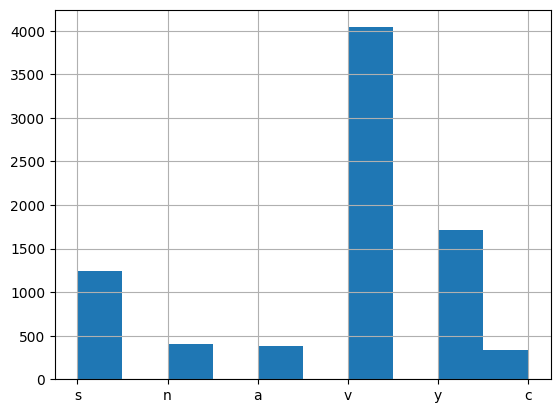

In [119]:
data['population'].hist()

# Missing Value Imputation

<Axes: >

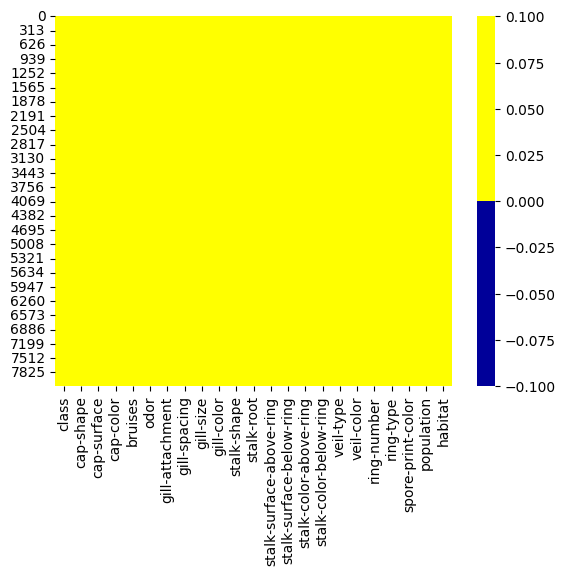

In [120]:
import seaborn as sns
cols=data.columns
colours=['#000099','#ffff00']
sns.heatmap(data[cols].isnull(),
            cmap=sns.color_palette(colours))

# Data Visulaisation


In [121]:
def plot_col(col, hue=None, color=['red', 'lightgreen'], labels=None):
    fig, ax = plt.subplots(figsize=(15, 7))
    sns.countplot(col, hue=hue, palette=color, saturation=0.6, data=data, dodge=True, ax=ax)
    ax.set(title = f"Mushroom {col.title()} Quantity", xlabel=f"{col.title()}", ylabel="Quantity")
    if labels!=None:
        ax.set_xticklabels(labels)
    if hue!=None:
        ax.legend(('Poisonous', 'Edible'), loc=0)

In [122]:
def get_labels(order, a_dict):    
    labels = []
    for values in order:
        for key, value in a_dict.items():
            if values == value:
                labels.append(key)
    return labels

In [123]:
pop_dict = {"abundant":"a","clustered":"c","numerous":"n","scattered":"s","several":"v","solitary":"y"}
hab_dict = {"grasses":"g","leaves":"l","meadows":"m","paths":"p","urban":"u","waste":"w","woods":"d"}

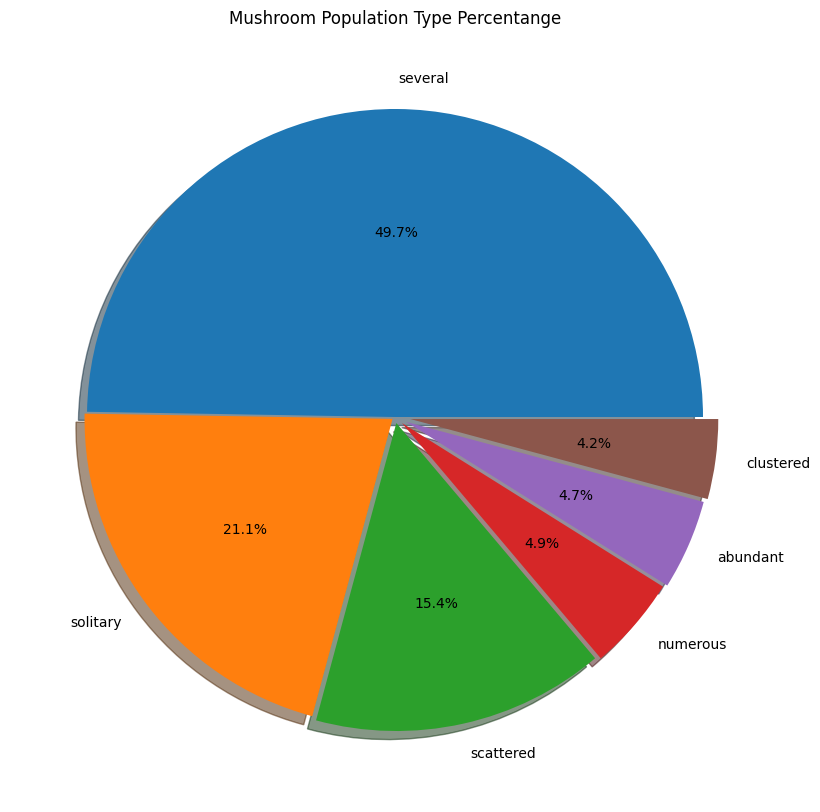

In [124]:
f, ax = plt.subplots(figsize=(15, 10))
order = list(data['population'].value_counts().index)
pop_labels = get_labels(order, pop_dict)
explode = (0.0,0.01,0.02,0.03,0.04,0.05)
data['population'].value_counts().plot.pie(explode=explode , autopct='%1.1f%%', labels=pop_labels, shadow=True, ax=ax)
ax.set_title('Mushroom Population Type Percentange');

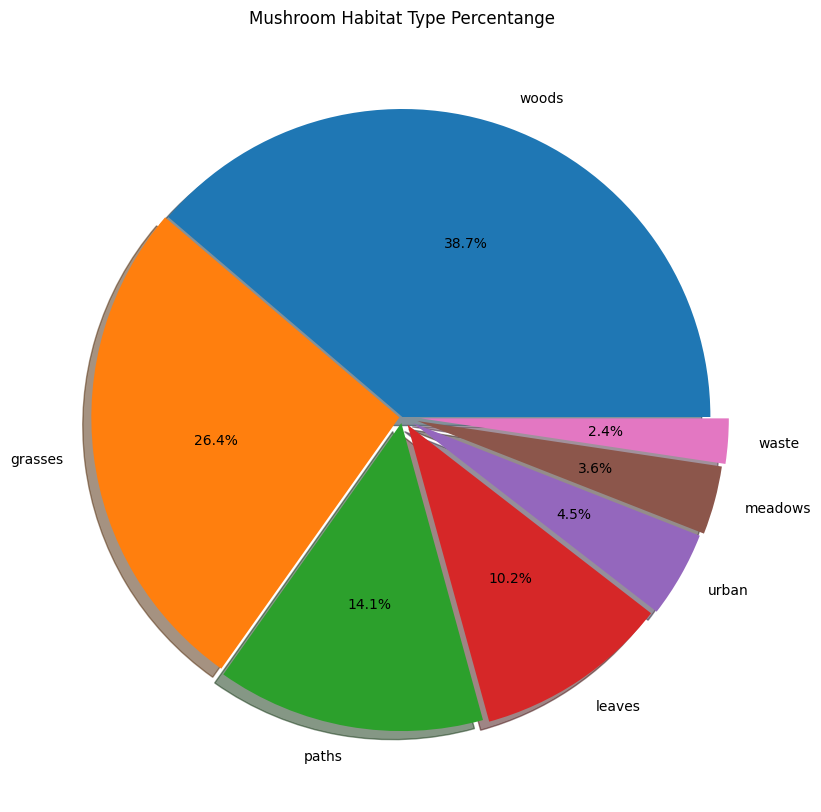

In [125]:
f, ax = plt.subplots(figsize=(15, 10))
order = list(data['habitat'].value_counts().index)
hab_labels = get_labels(order, hab_dict)
explode = (0.0,0.01,0.02,0.03,0.04,0.05, 0.06)
data['habitat'].value_counts().plot.pie(explode=explode, autopct='%1.1f%%', labels=hab_labels, shadow=True, ax=ax)
ax.set_title('Mushroom Habitat Type Percentange');

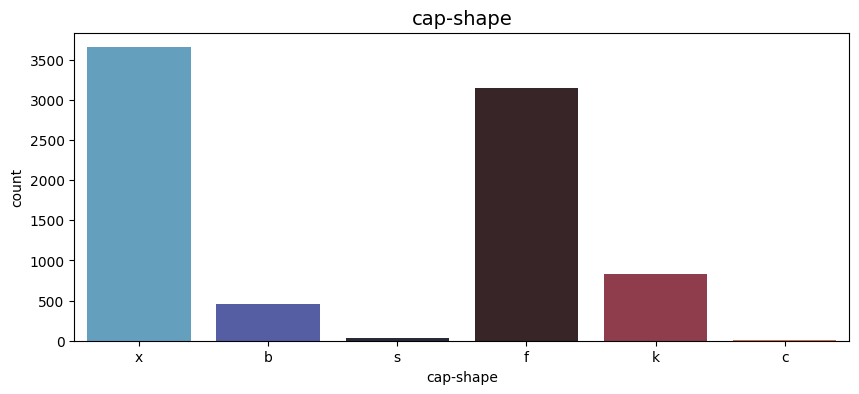

% of total:
cap-shape
x    45.00
f    38.80
k    10.19
b     5.56
s     0.39
c     0.05
Name: count, dtype: float64


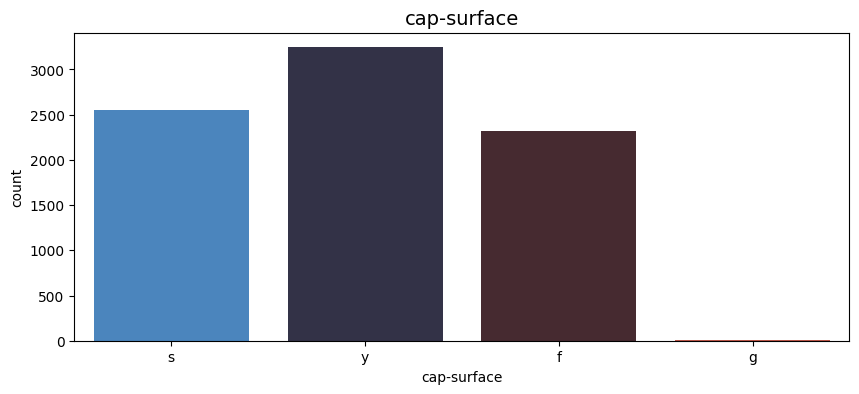

% of total:
cap-surface
y    39.93
s    31.46
f    28.56
g     0.05
Name: count, dtype: float64


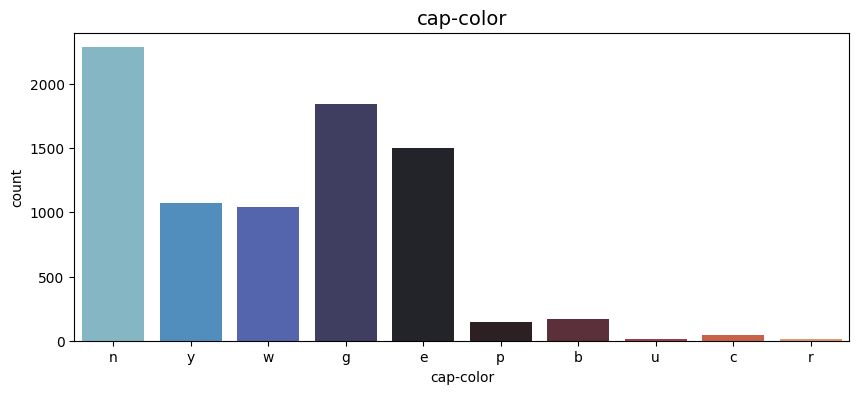

% of total:
cap-color
n    28.11
g    22.65
e    18.46
y    13.20
w    12.80
b     2.07
p     1.77
c     0.54
u     0.20
r     0.20
Name: count, dtype: float64


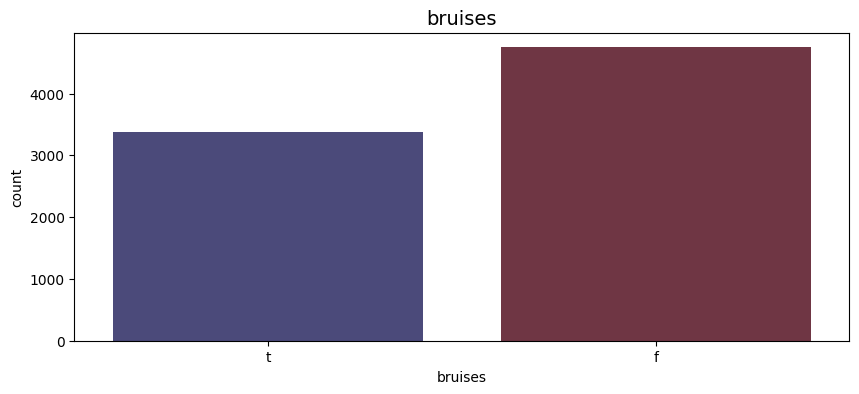

% of total:
bruises
f    58.44
t    41.56
Name: count, dtype: float64


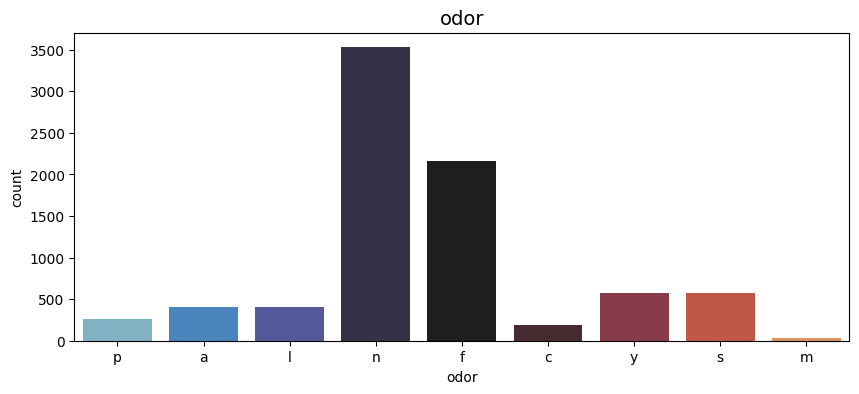

% of total:
odor
n    43.43
f    26.59
y     7.09
s     7.09
a     4.92
l     4.92
p     3.15
c     2.36
m     0.44
Name: count, dtype: float64


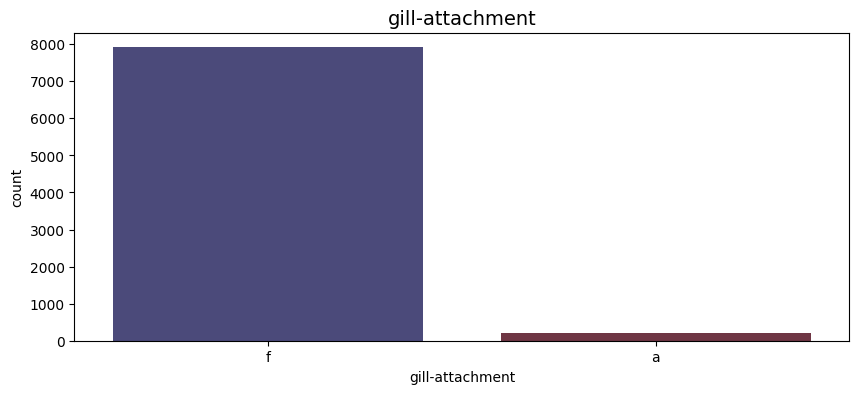

% of total:
gill-attachment
f    97.42
a     2.58
Name: count, dtype: float64


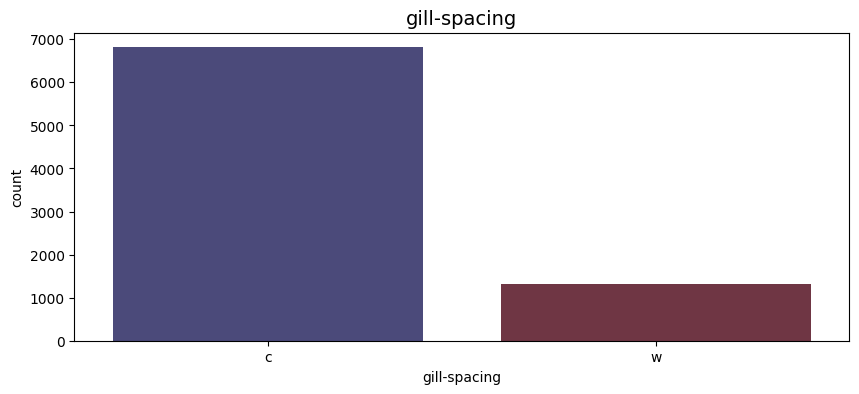

% of total:
gill-spacing
c    83.85
w    16.15
Name: count, dtype: float64


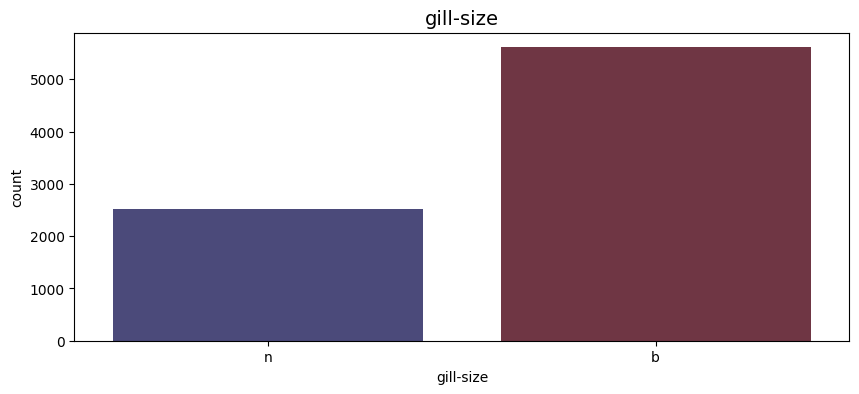

% of total:
gill-size
b    69.08
n    30.92
Name: count, dtype: float64


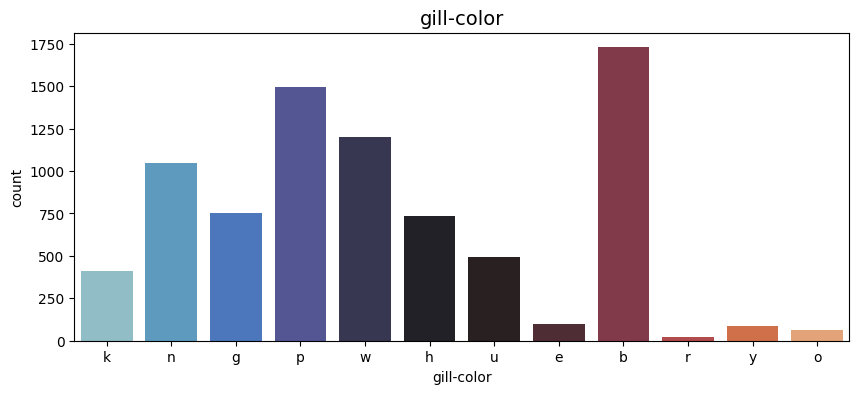

% of total:
gill-color
b    21.27
p    18.37
w    14.80
n    12.90
g     9.26
h     9.01
u     6.06
k     5.02
e     1.18
y     1.06
o     0.79
r     0.30
Name: count, dtype: float64


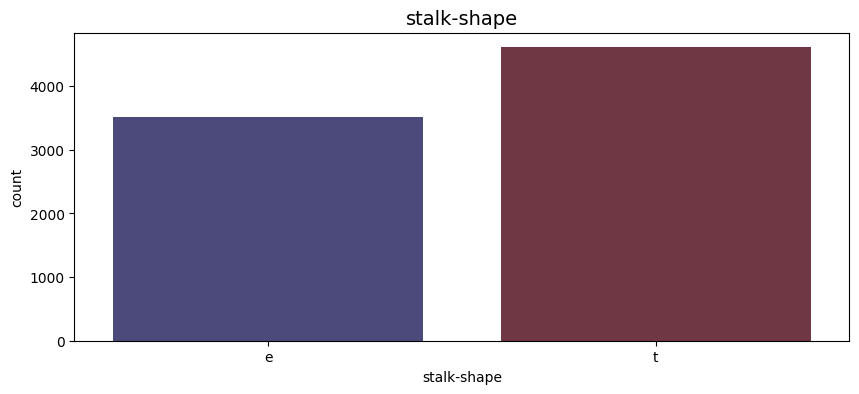

% of total:
stalk-shape
t    56.72
e    43.28
Name: count, dtype: float64


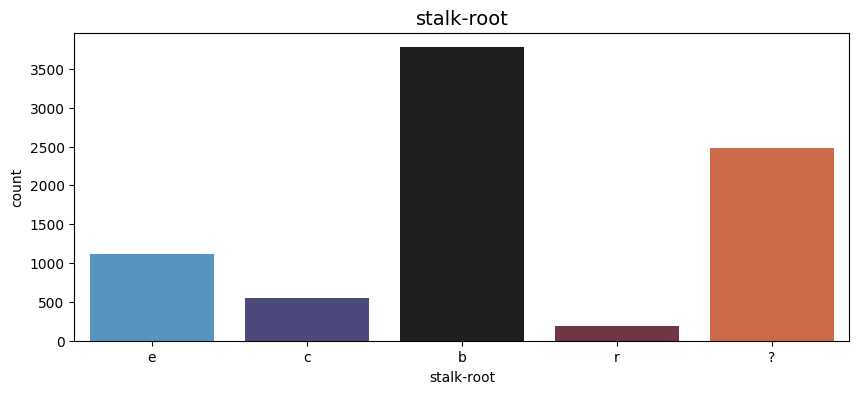

% of total:
stalk-root
b    46.48
?    30.53
e    13.79
c     6.84
r     2.36
Name: count, dtype: float64


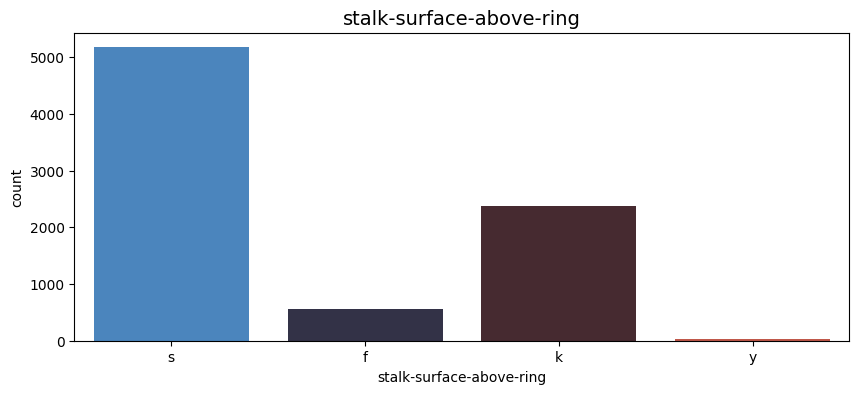

% of total:
stalk-surface-above-ring
s    63.71
k    29.20
f     6.79
y     0.30
Name: count, dtype: float64


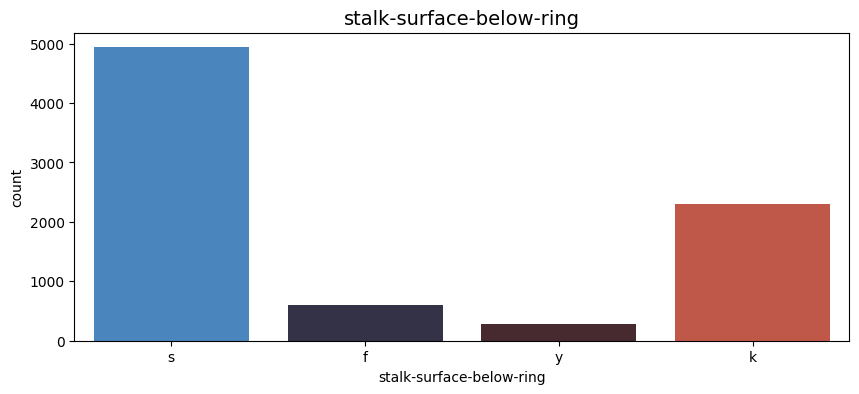

% of total:
stalk-surface-below-ring
s    60.76
k    28.36
f     7.39
y     3.50
Name: count, dtype: float64


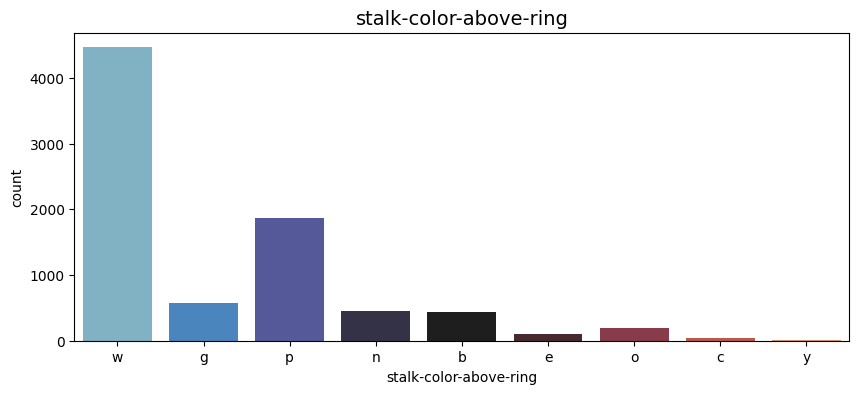

% of total:
stalk-color-above-ring
w    54.95
p    23.04
g     7.09
n     5.51
b     5.32
o     2.36
e     1.18
c     0.44
y     0.10
Name: count, dtype: float64


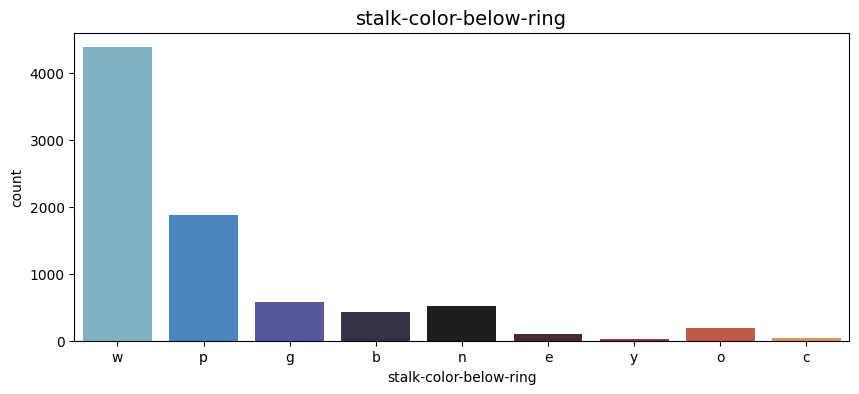

% of total:
stalk-color-below-ring
w    53.96
p    23.04
g     7.09
n     6.30
b     5.32
o     2.36
e     1.18
c     0.44
y     0.30
Name: count, dtype: float64


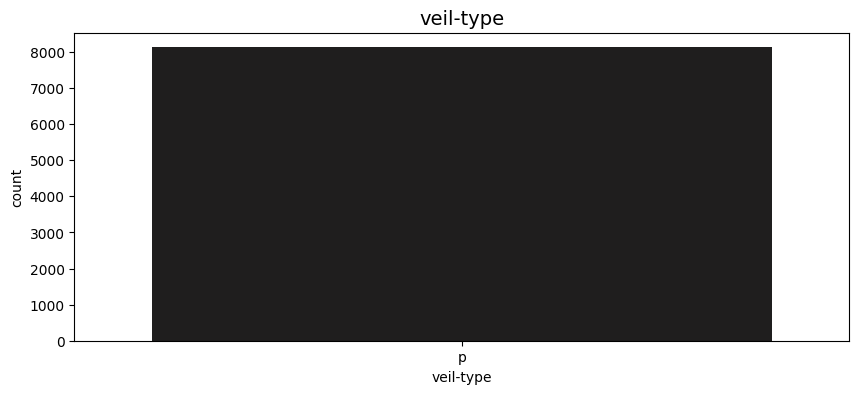

% of total:
veil-type
p    100.0
Name: count, dtype: float64


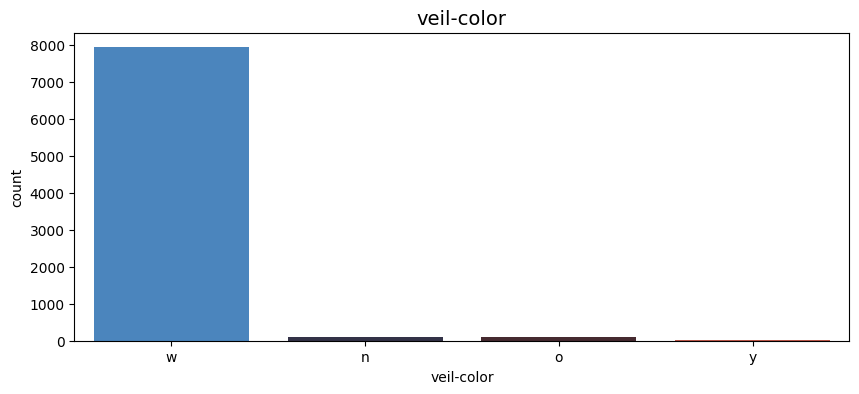

% of total:
veil-color
w    97.54
n     1.18
o     1.18
y     0.10
Name: count, dtype: float64


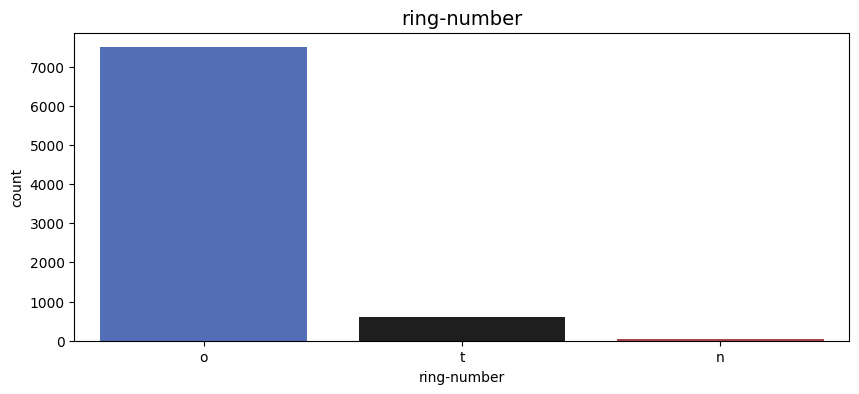

% of total:
ring-number
o    92.17
t     7.39
n     0.44
Name: count, dtype: float64


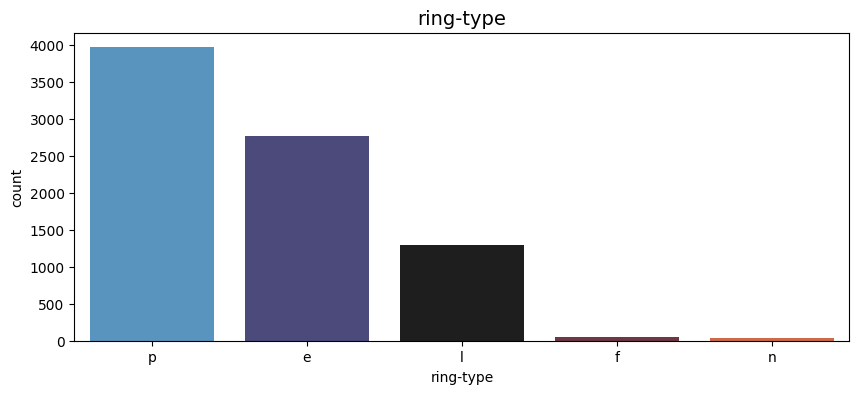

% of total:
ring-type
p    48.84
e    34.17
l    15.95
f     0.59
n     0.44
Name: count, dtype: float64


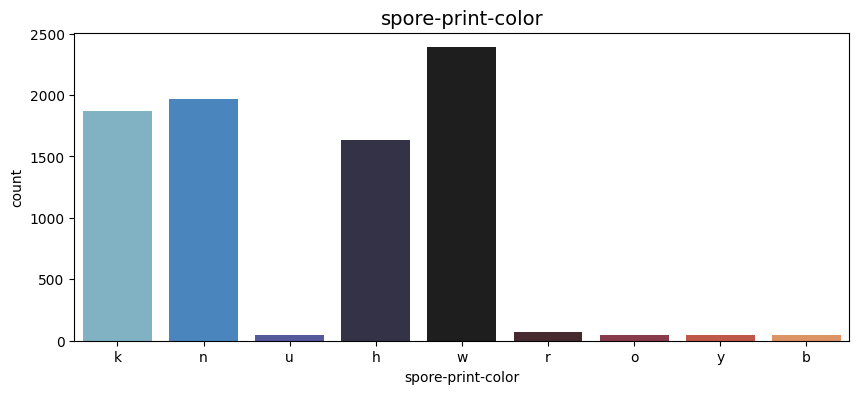

% of total:
spore-print-color
w    29.39
n    24.22
k    23.04
h    20.09
r     0.89
u     0.59
o     0.59
y     0.59
b     0.59
Name: count, dtype: float64


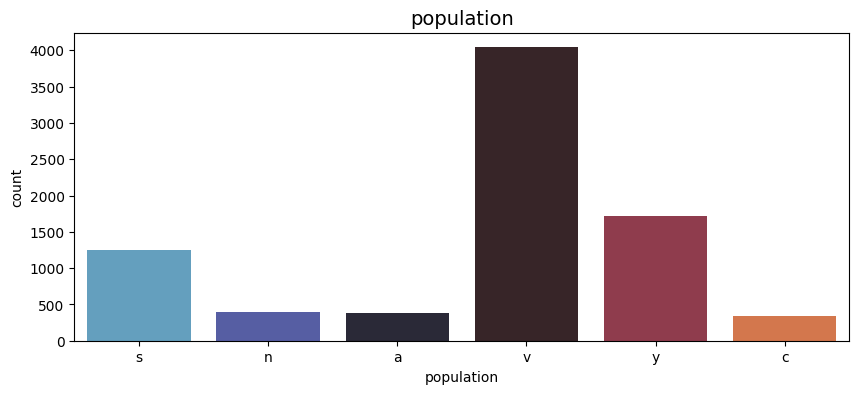

% of total:
population
v    49.73
y    21.07
s    15.36
n     4.92
a     4.73
c     4.19
Name: count, dtype: float64


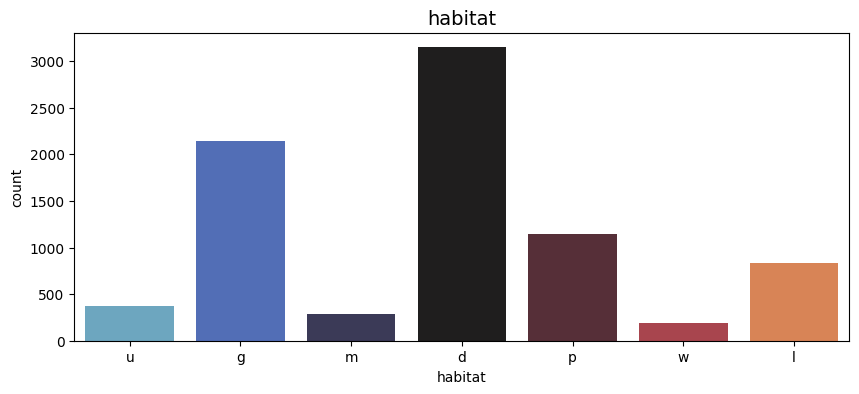

% of total:
habitat
d    38.75
g    26.44
p    14.08
l    10.24
u     4.53
m     3.59
w     2.36
Name: count, dtype: float64


In [126]:
for col in M_cols[1:]:
    plt.figure(figsize=(10,4))
    sns.countplot(x=col , data=data ,palette='icefire')
    plt.title(col, fontsize=14)
    plt.show()
    print("% of total:")
    print(round((data[col].value_counts()/data.shape[0]),4)*100)

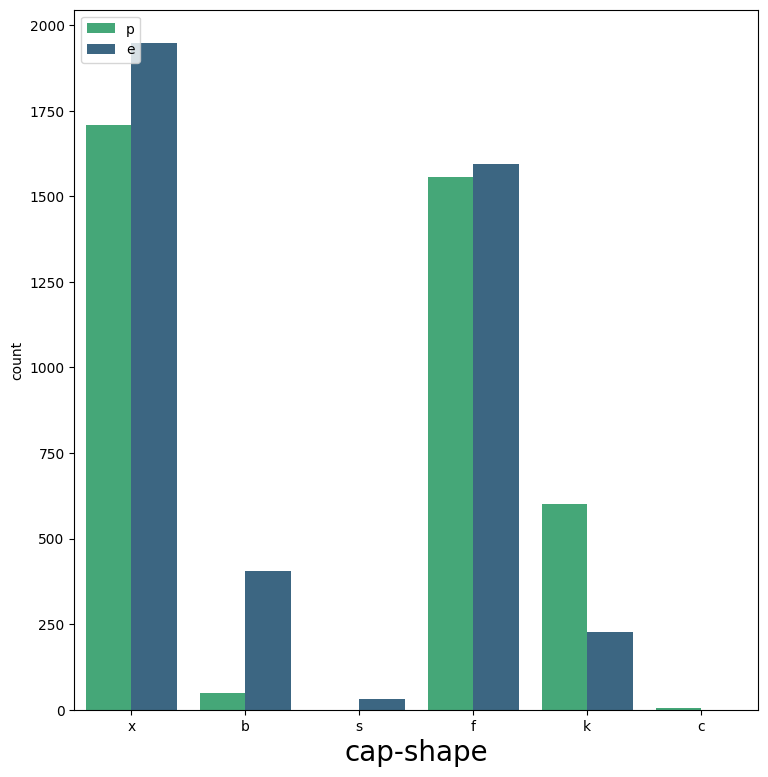

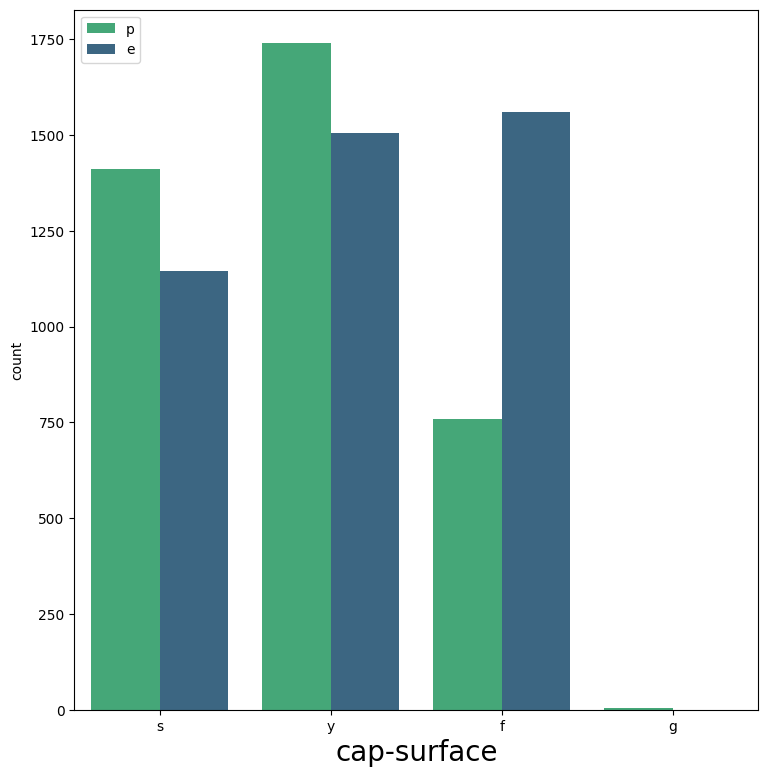

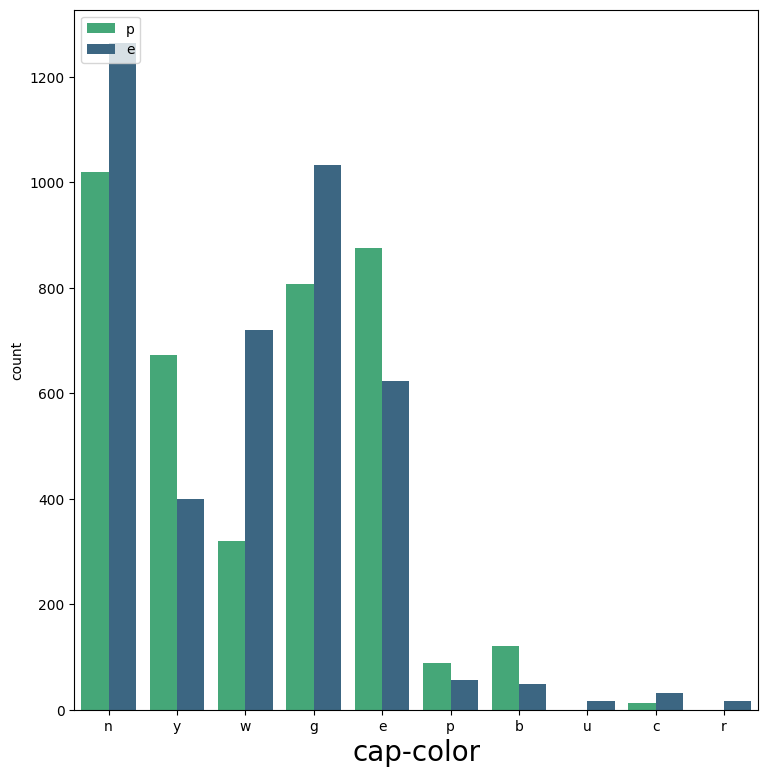

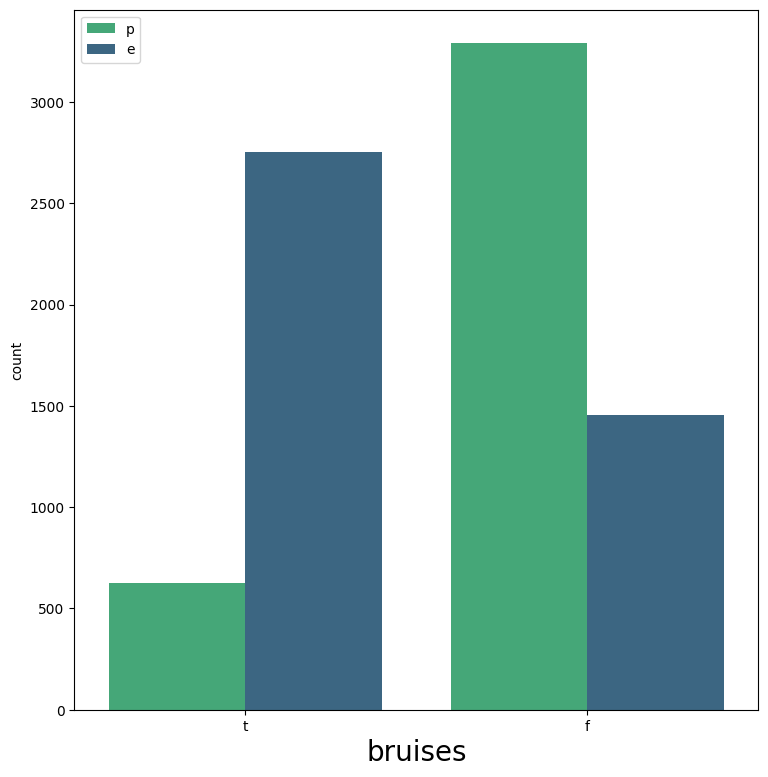

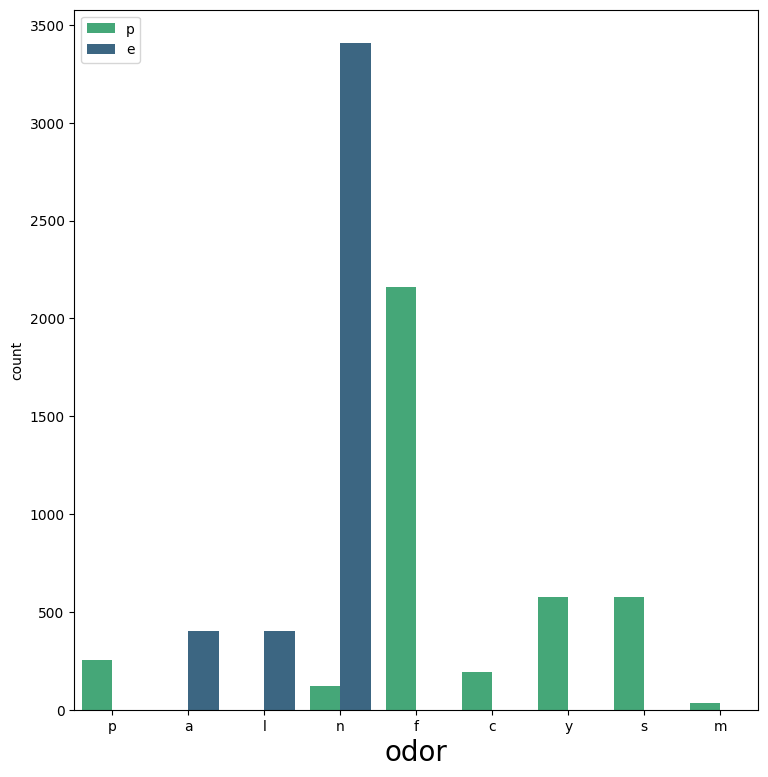

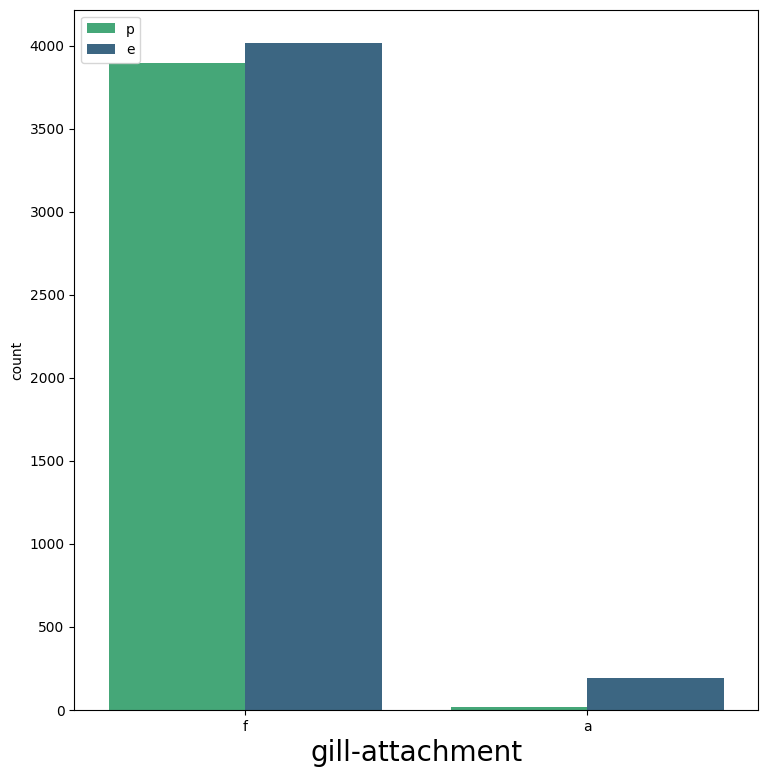

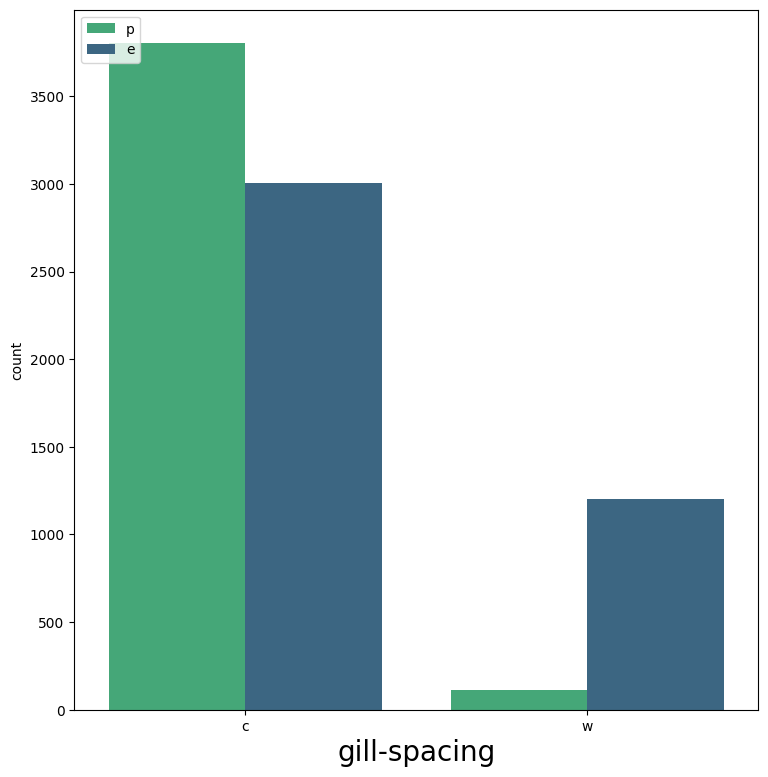

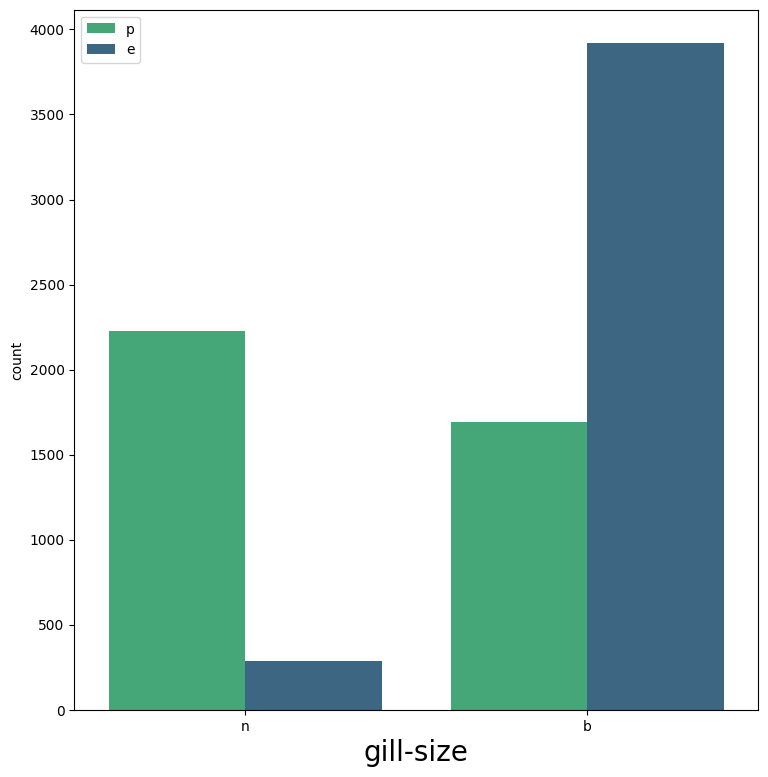

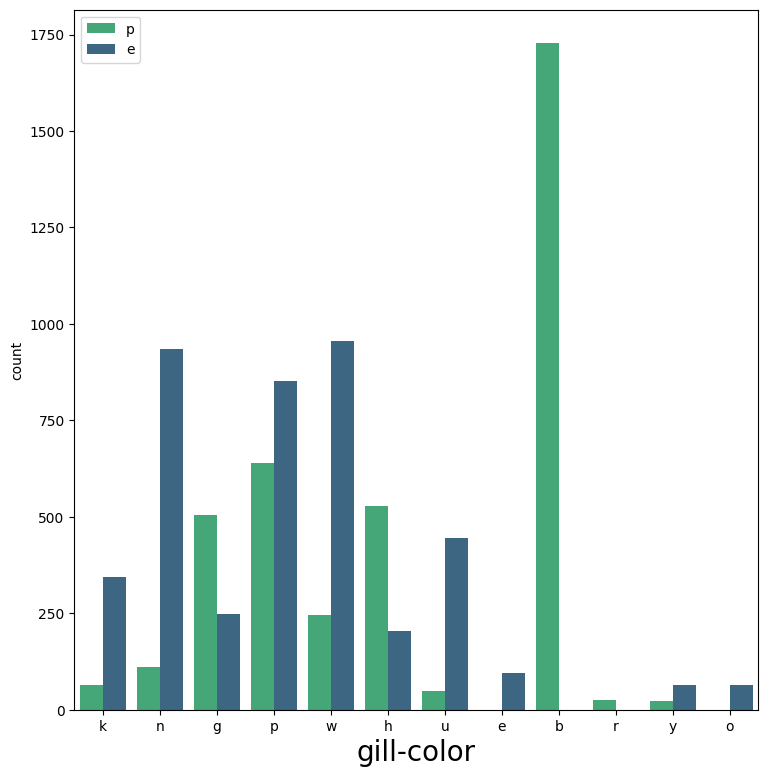

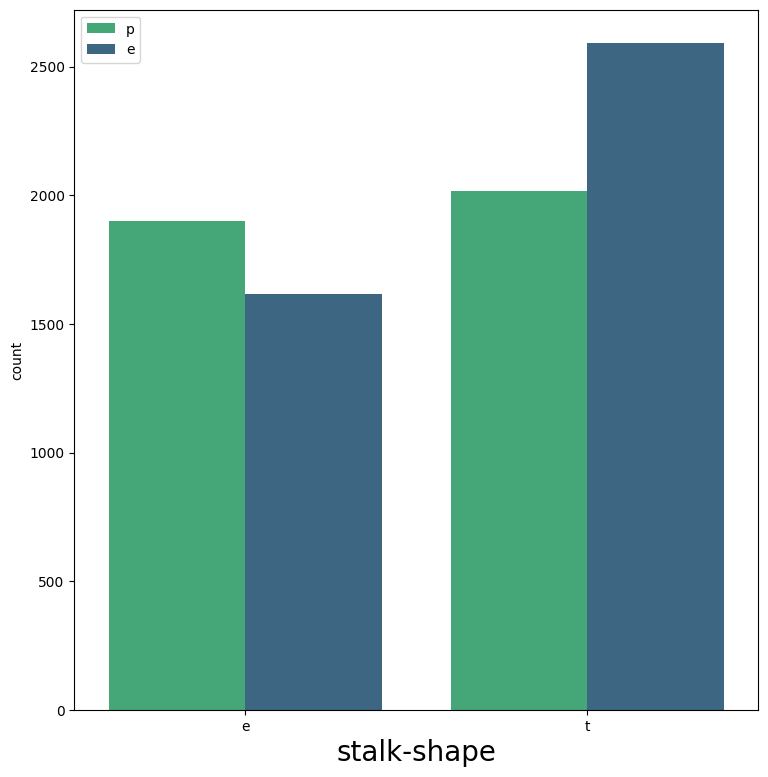

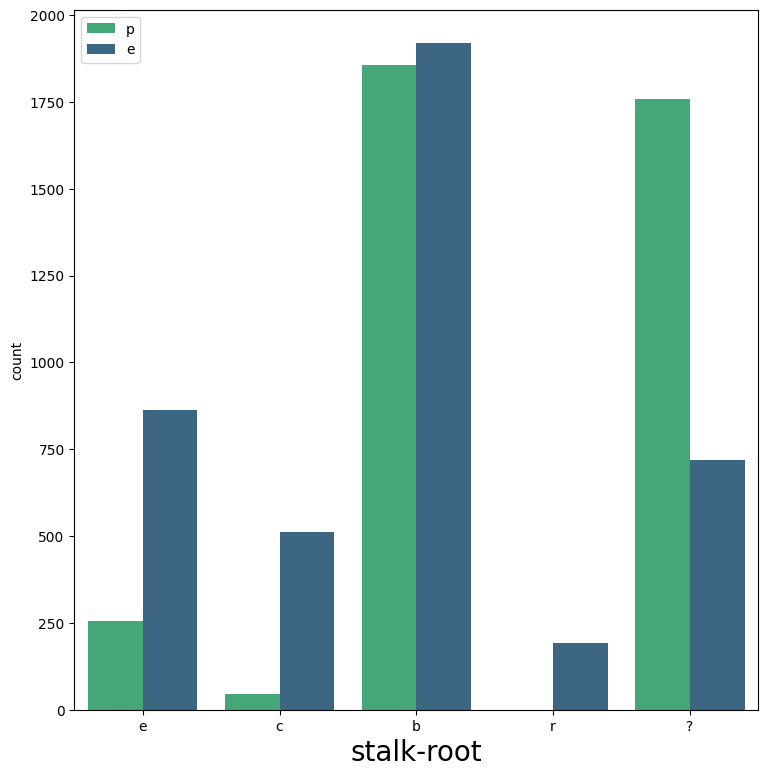

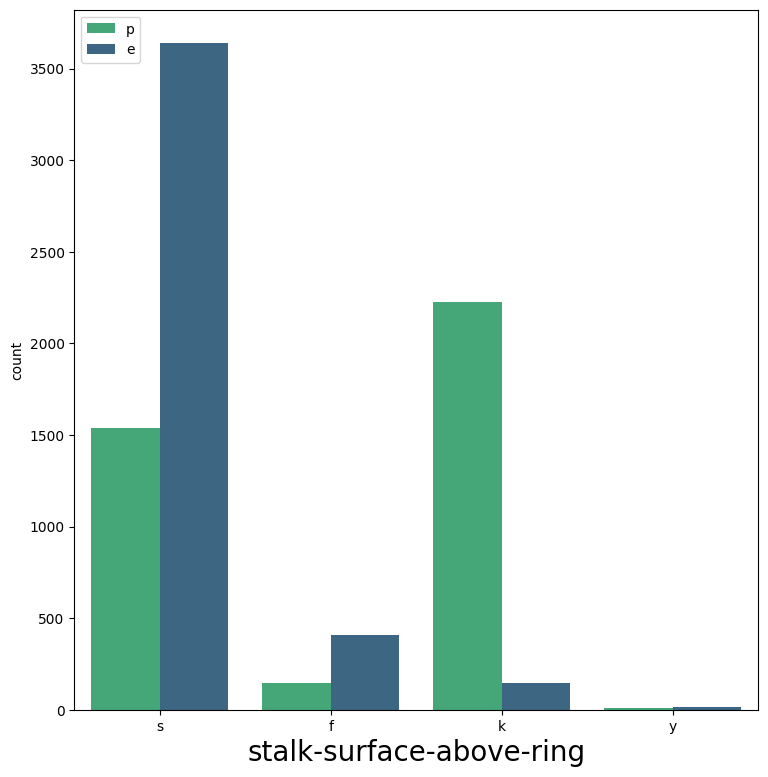

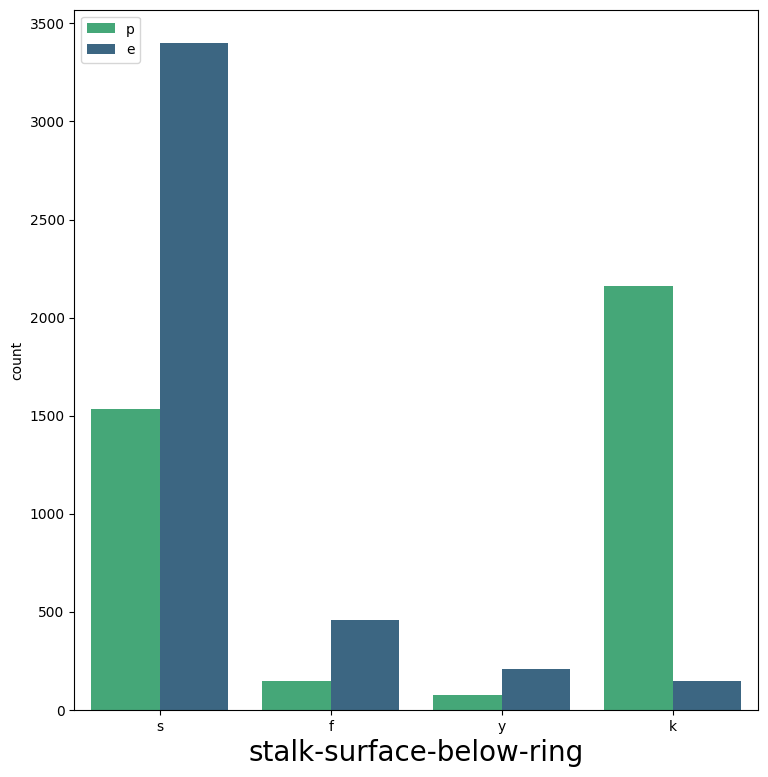

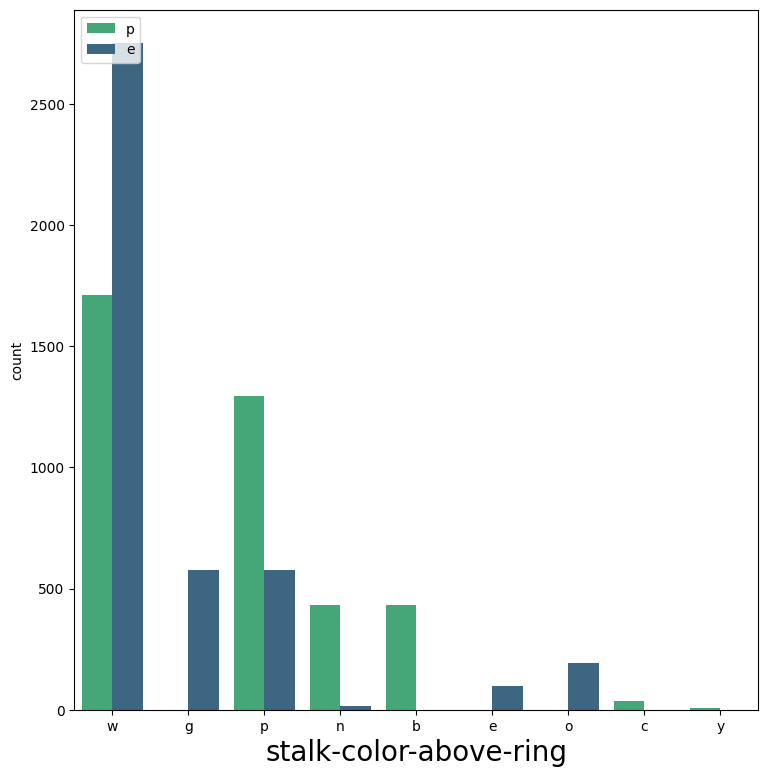

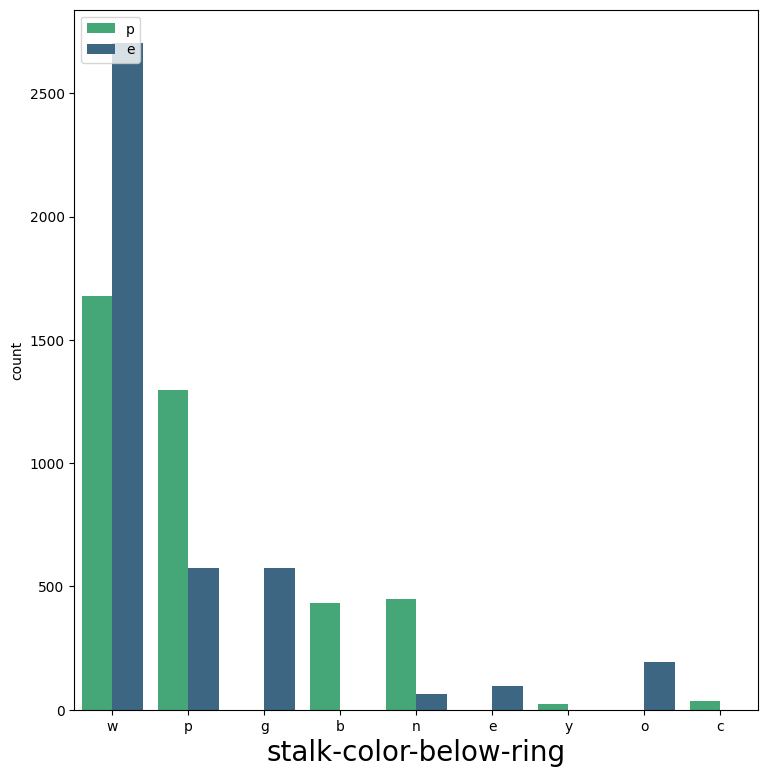

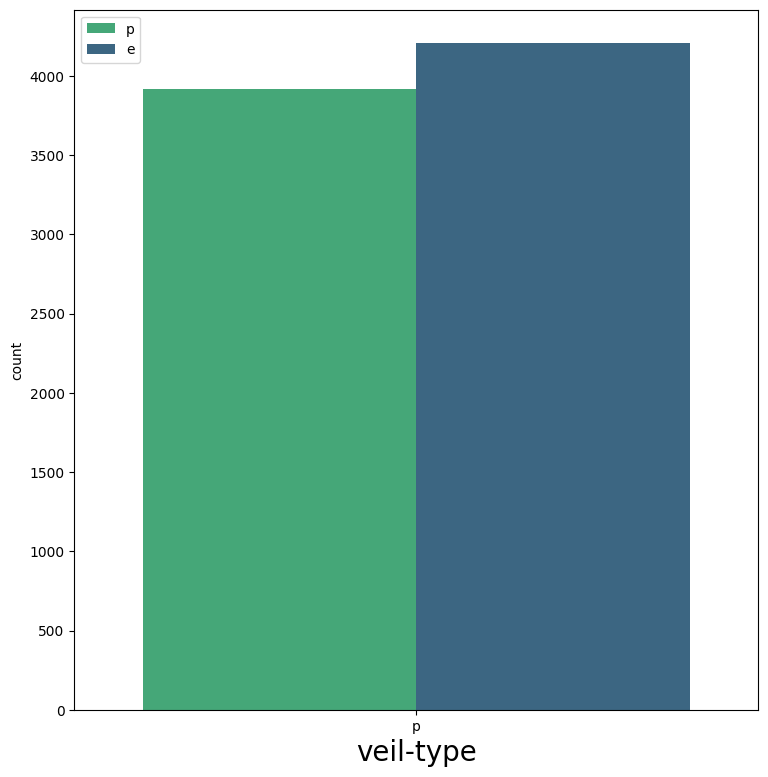

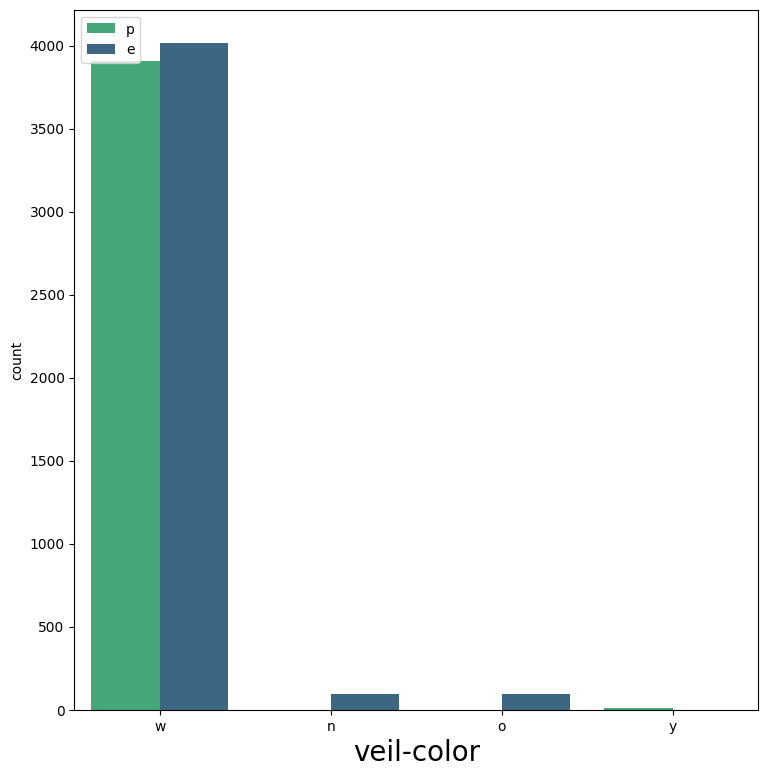

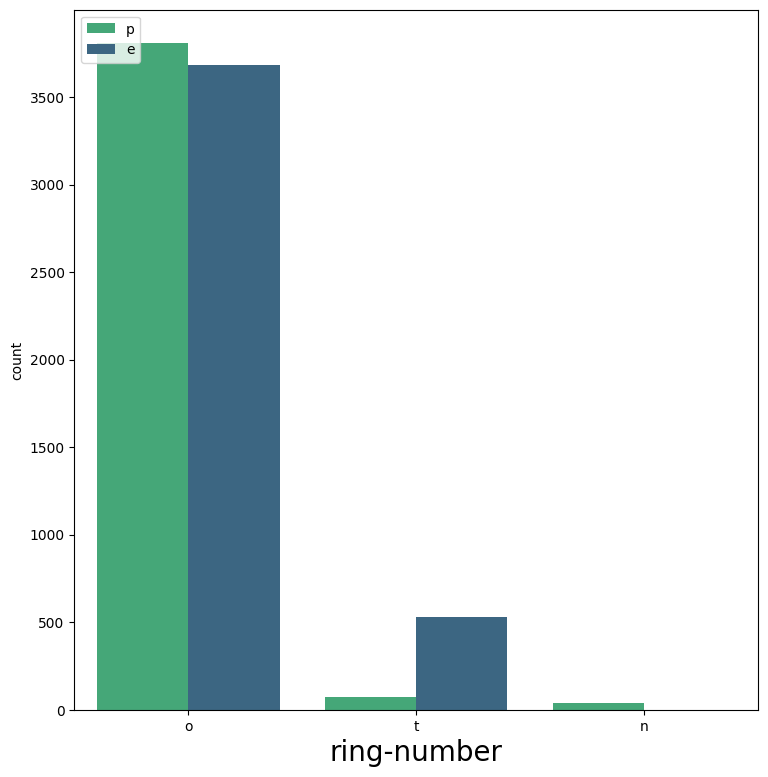

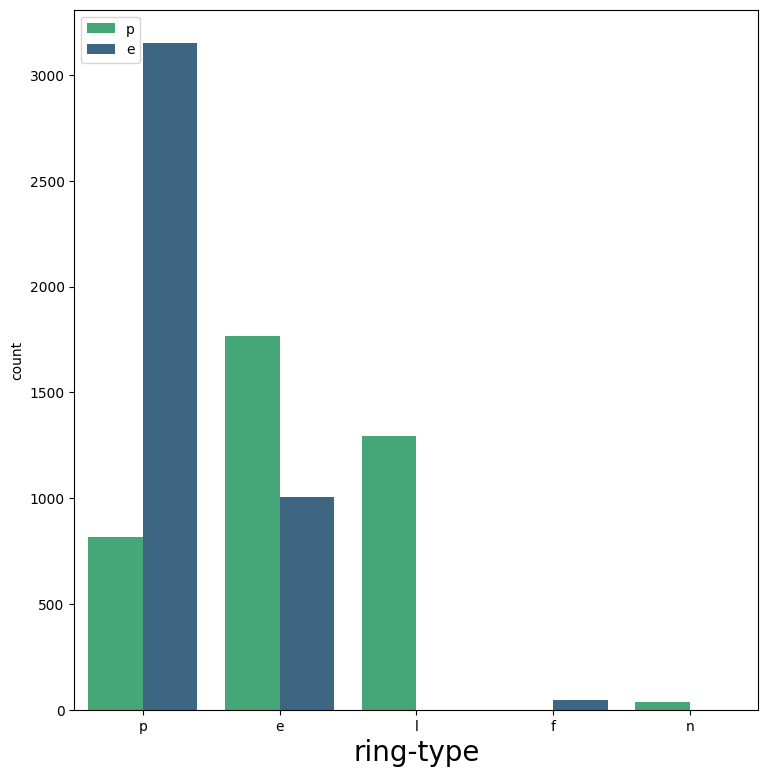

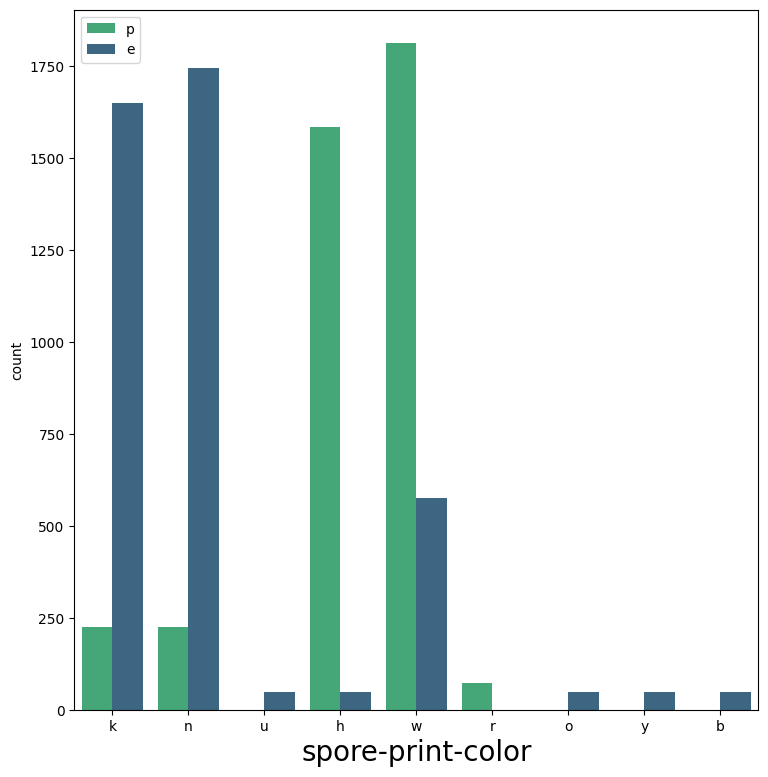

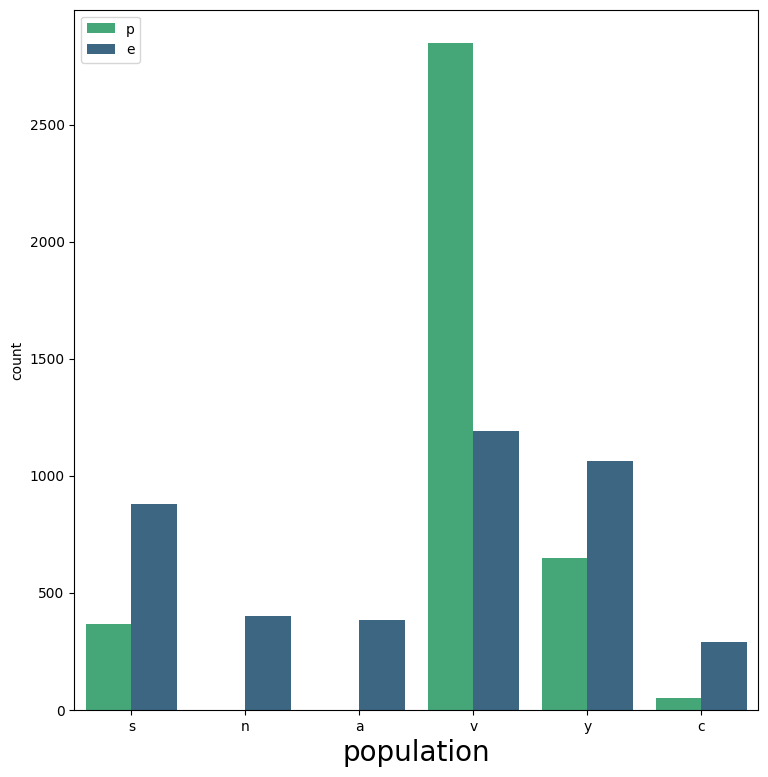

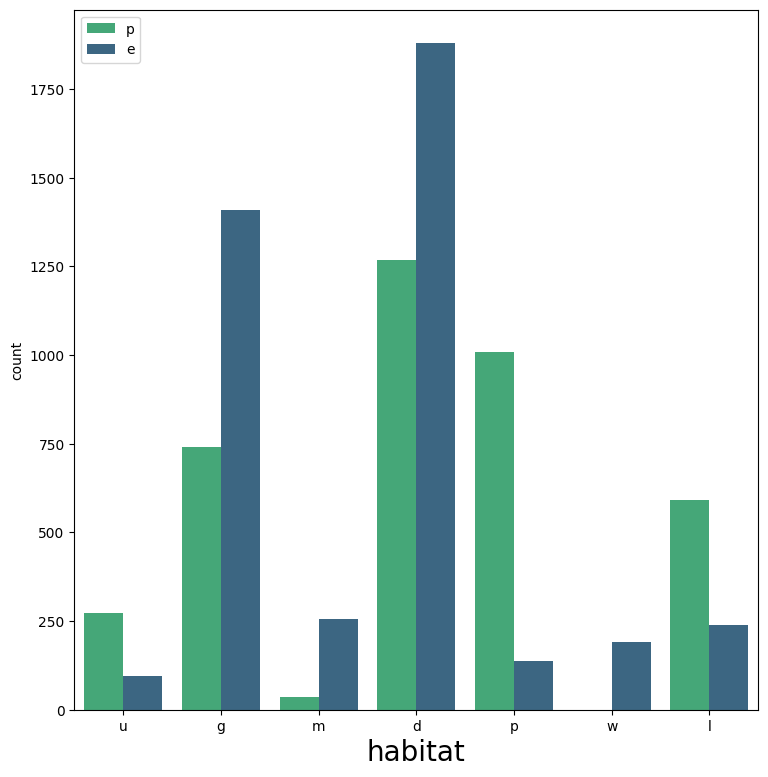

In [127]:
for col in M_cols[1:]: 
    plt.figure(figsize=(30,20))
    plt.subplot(2,3,1)
    sns.countplot(x=col ,hue='class', data=data ,palette='viridis_r')
    plt.xlabel(col, fontsize=20)
    plt.legend(loc='upper left')

In [128]:
data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [129]:
data.tail()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,o,c,l


# Label Encoding

In [130]:
from sklearn.preprocessing import LabelEncoder  # Import LabelEncoder class

label_encoder = LabelEncoder()  # Create a instance for the label encoder
encoded_data = pd.DataFrame()  # Create empty DataFrame

for column in data.columns:
    encoded_data[column] = label_encoder.fit_transform(data[column])

In [131]:
encoded_data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


In [132]:
encoded_data.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,...,8124.000000,8124.000000,8124.000000,8124.0,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000
mean,0.482029,3.348104,1.827671,4.504677,0.415559,4.144756,0.974151,0.161497,0.309207,4.810684,...,1.603644,5.816347,5.794682,0.0,1.965534,1.069424,2.291974,3.596750,3.644018,1.508616
std,0.499708,1.604329,1.229873,2.545821,0.492848,2.103729,0.158695,0.368011,0.462195,3.540359,...,0.675974,1.901747,1.907291,0.0,0.242669,0.271064,1.801672,2.382663,1.252082,1.719975
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,3.000000,0.000000,2.000000,1.000000,0.000000,0.000000,2.000000,...,1.000000,6.000000,6.000000,0.0,2.000000,1.000000,0.000000,2.000000,3.000000,0.000000
50%,0.000000,3.000000,2.000000,4.000000,0.000000,5.000000,1.000000,0.000000,0.000000,5.000000,...,2.000000,7.000000,7.000000,0.0,2.000000,1.000000,2.000000,3.000000,4.000000,1.000000
75%,1.000000,5.000000,3.000000,8.000000,1.000000,5.000000,1.000000,0.000000,1.000000,7.000000,...,2.000000,7.000000,7.000000,0.0,2.000000,1.000000,4.000000,7.000000,4.000000,2.000000
max,1.000000,5.000000,3.000000,9.000000,1.000000,8.000000,1.000000,1.000000,1.000000,11.000000,...,3.000000,8.000000,8.000000,0.0,3.000000,2.000000,4.000000,8.000000,5.000000,6.000000


In [133]:
encoded_data.corr()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
class,1.000000,0.052951,0.178446,-0.031384,-0.501530,-0.093552,0.129200,-0.348387,0.540024,-0.530566,...,-0.298801,-0.154003,-0.146730,NaN,0.145142,-0.214366,-0.411771,0.171961,0.298686,0.217179
cap-shape,0.052951,1.000000,-0.050454,-0.048203,-0.035374,-0.021935,0.078865,0.013196,0.054050,-0.006039,...,-0.032591,-0.031659,-0.030390,NaN,0.072560,-0.106534,-0.025457,-0.073416,0.063413,-0.042221
cap-surface,0.178446,-0.050454,1.000000,-0.019402,0.070228,0.045233,-0.034180,-0.282306,0.208100,-0.161017,...,0.107965,0.066050,0.068885,NaN,-0.016603,-0.026147,-0.106407,0.230364,0.021555,0.163887
cap-color,-0.031384,-0.048203,-0.019402,1.000000,-0.000764,-0.387121,0.041436,0.144259,-0.169464,0.084659,...,-0.047710,0.002364,0.008057,NaN,0.036130,-0.005822,0.162513,-0.293523,-0.144770,0.033925
bruises,-0.501530,-0.035374,0.070228,-0.000764,1.000000,-0.061825,0.137359,-0.299473,-0.369596,0.527120,...,0.458983,0.083538,0.092874,NaN,0.119770,0.056788,0.692973,-0.285008,0.088137,-0.075095
odor,-0.093552,-0.021935,0.045233,-0.387121,-0.061825,1.000000,-0.059590,0.063936,0.310495,-0.129213,...,0.061820,0.174532,0.169407,NaN,-0.057747,0.111905,-0.281387,0.469055,-0.043623,-0.026610
gill-attachment,0.129200,0.078865,-0.034180,0.041436,0.137359,-0.059590,1.000000,0.071489,0.108984,-0.128567,...,-0.116177,0.099299,0.097160,NaN,0.897518,0.093236,-0.146689,-0.029524,0.165575,-0.030304
gill-spacing,-0.348387,0.013196,-0.282306,0.144259,-0.299473,0.063936,0.071489,1.000000,-0.108333,0.100193,...,-0.213775,0.274574,0.253505,NaN,0.073363,0.243014,-0.195897,0.047323,-0.529253,-0.154680
gill-size,0.540024,0.054050,0.208100,-0.169464,-0.369596,0.310495,0.108984,-0.108333,1.000000,-0.516736,...,0.010894,0.296548,0.278708,NaN,0.103809,-0.171362,-0.460872,0.622991,0.147682,0.161418
gill-color,-0.530566,-0.006039,-0.161017,0.084659,0.527120,-0.129213,-0.128567,0.100193,-0.516736,1.000000,...,0.257224,-0.058299,-0.074781,NaN,-0.097583,0.096054,0.629398,-0.416135,-0.034090,-0.202972


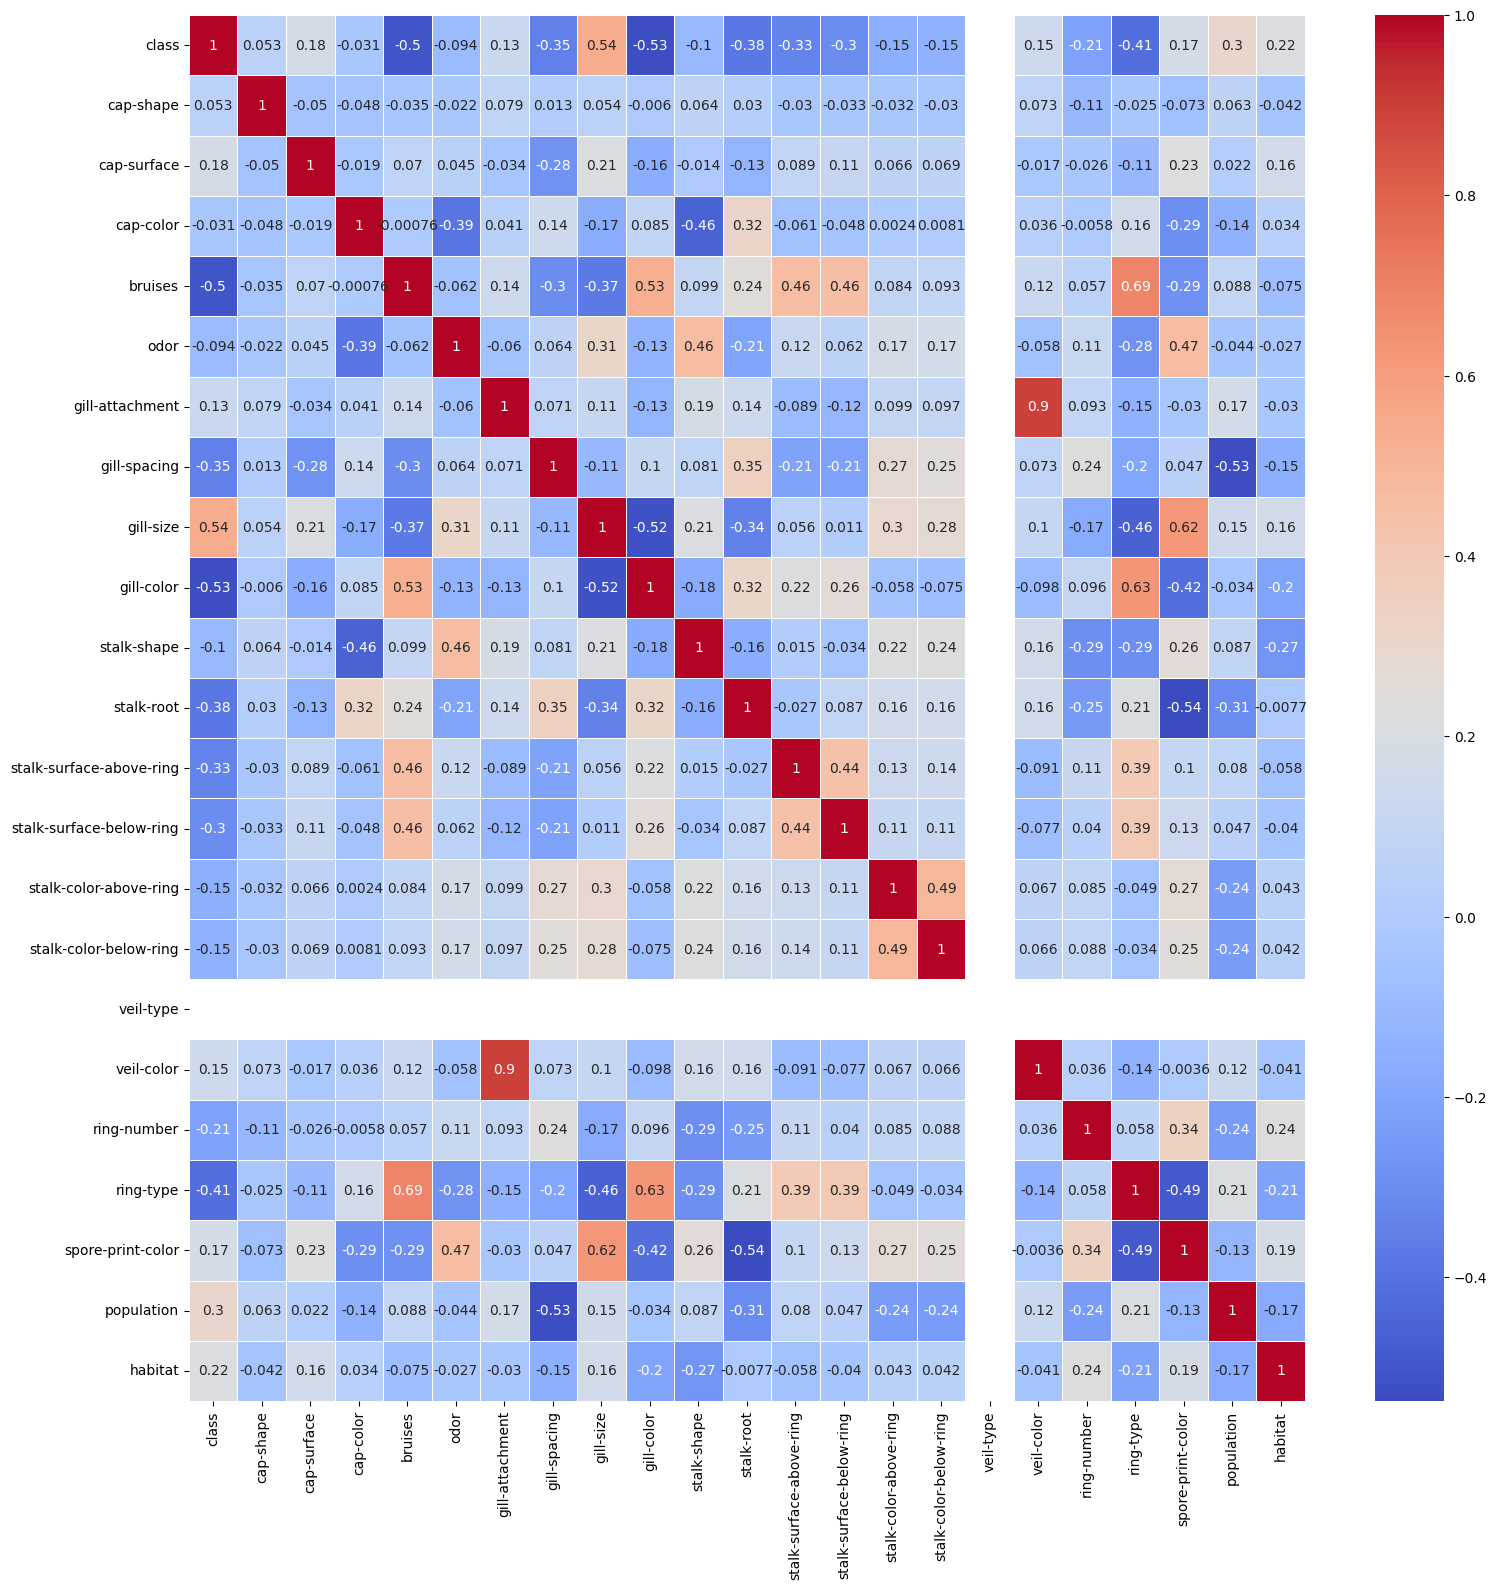

In [134]:
fig, axes = plt.subplots(figsize=(18, 18))  # This method creates a figure and a set of subplots
sns.heatmap(data=encoded_data.corr(), annot=True, linewidths=.5, cmap="coolwarm", ax=axes)  # Figure out heatmap
plt.show() 

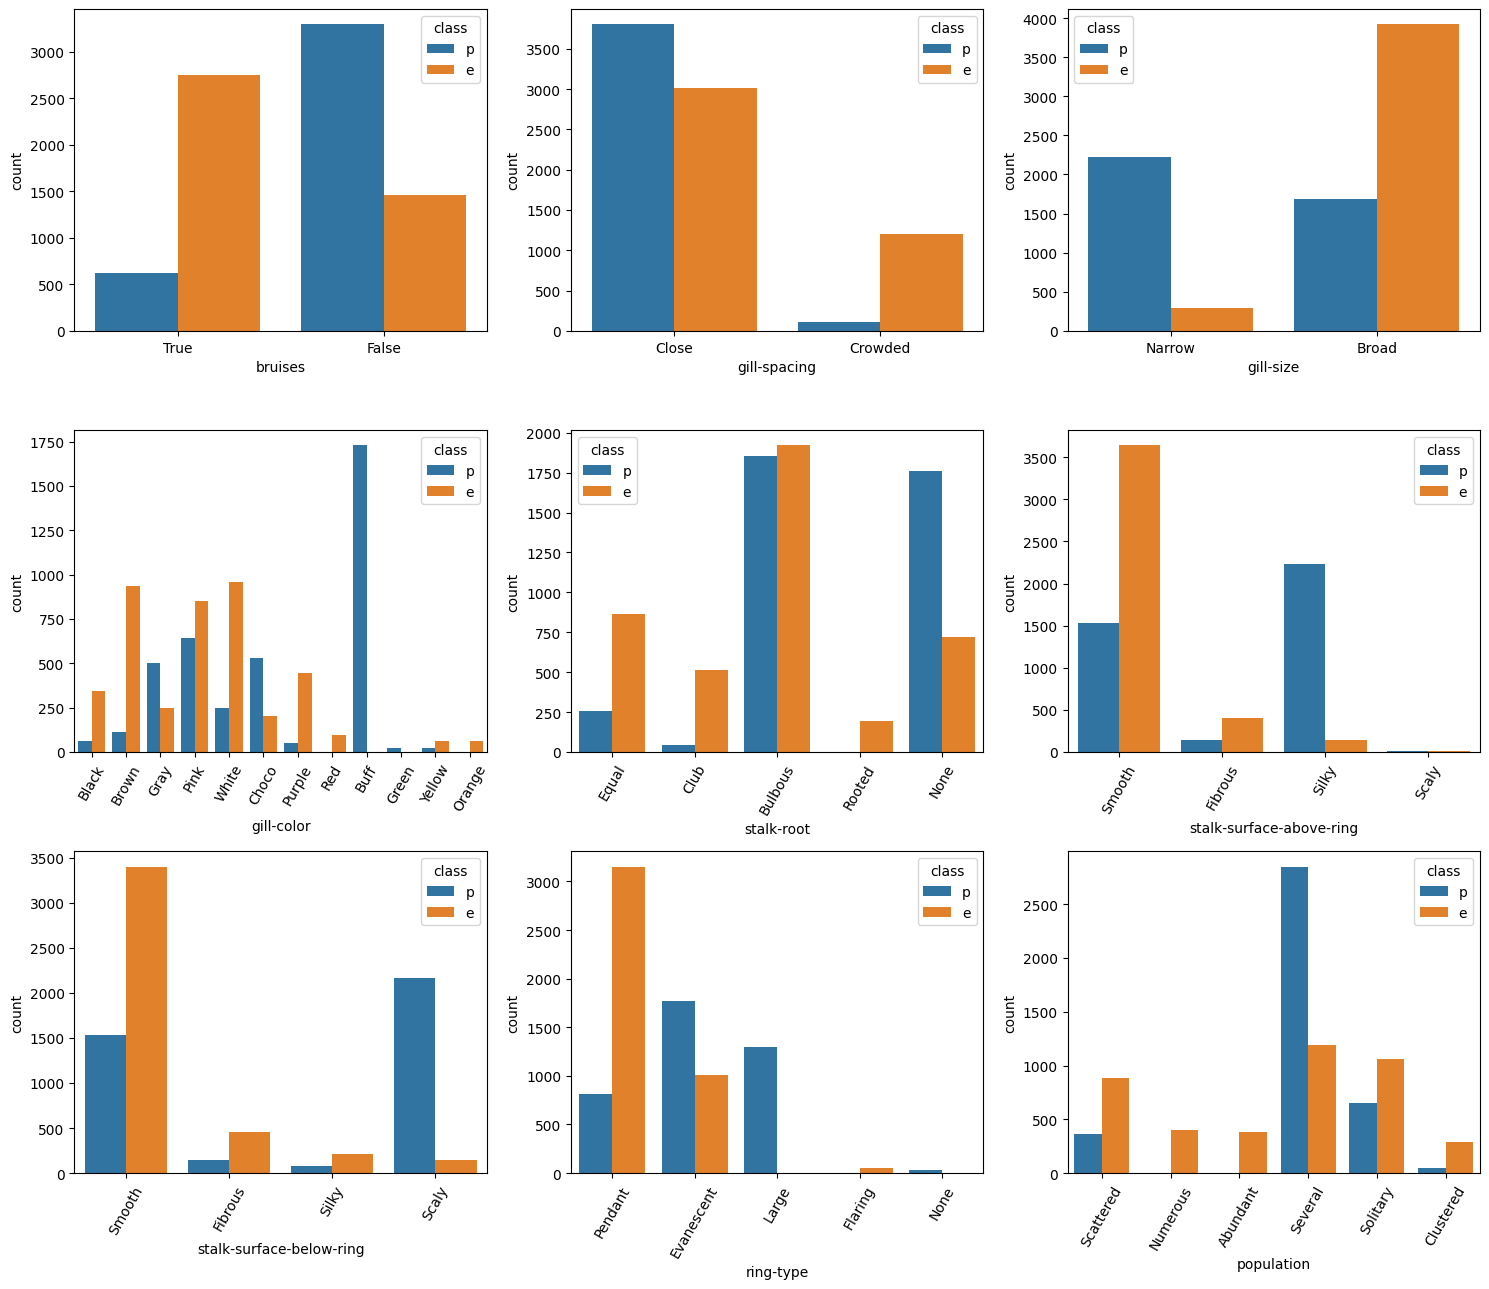

In [135]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 13))  # Adjust subplots

# Draw frequency of the "bruises" values according to "class":
bruises_bar = sns.countplot(x="bruises", hue="class", data=data, ax=axes[0][0]);
bruises_bar.set_xticklabels(["True", "False"])

# Draw frequency of the "gill-spacing" values according to "class":
gill_spacing_bar = sns.countplot(x="gill-spacing", hue="class", data=data, ax=axes[0][1]);
gill_spacing_bar.set_xticklabels(["Close", "Crowded", ])

# Draw frequency of the "gill-size" values according to "class":
gill_size_bar = sns.countplot(x="gill-size", hue="class", data=data, ax=axes[0][2]);
gill_size_bar.set_xticklabels(["Narrow", "Broad"])

# Draw frequency of the "gill-color" values according to "class":
gill_color_bar = sns.countplot(x="gill-color", hue="class", data=data, ax=axes[1][0]);
gill_color_bar.set_xticklabels(["Black", "Brown", "Gray", "Pink", "White", "Choco", "Purple", "Red", "Buff", "Green", "Yellow", "Orange"], rotation=60)

# Draw frequency of the "stalk-root" values according to "class":
stalk_root_bar = sns.countplot(x="stalk-root", hue="class", data=data, ax=axes[1][1]);
stalk_root_bar.set_xticklabels(["Equal", "Club", "Bulbous", "Rooted", "None"], rotation=60)

# Draw frequency of the "stalk-surface-above-ring" values according to "class":
stalk_sar_bar = sns.countplot(x="stalk-surface-above-ring", hue="class", data=data, ax=axes[1][2]);
stalk_sar_bar.set_xticklabels(["Smooth", "Fibrous", "Silky", "Scaly"], rotation=60)

# Draw frequency of the "stalk-surface-below-ring" values according to "class":
stalk_sbr_bar = sns.countplot(x="stalk-surface-below-ring", hue="class", data=data, ax=axes[2][0]);
stalk_sbr_bar.set_xticklabels(["Smooth", "Fibrous", "Silky", "Scaly"], rotation=60)

# Draw frequency of the "ring-type" values according to "class":
ring_type_bar = sns.countplot(x="ring-type", hue="class", data=data, ax=axes[2][1]);
ring_type_bar.set_xticklabels(["Pendant", "Evanescent", "Large", "Flaring", "None"], rotation=60)

# Draw frequency of the "population" values according to "class":
population_bar = sns.countplot(x="population", hue="class", data=data, ax=axes[2][2]);
population_bar.set_xticklabels(["Scattered", "Numerous", "Abundant", "Several", "Solitary", "Clustered"], rotation=60)

fig.tight_layout()  # Slightly spacing between axis labels and values
plt.show()

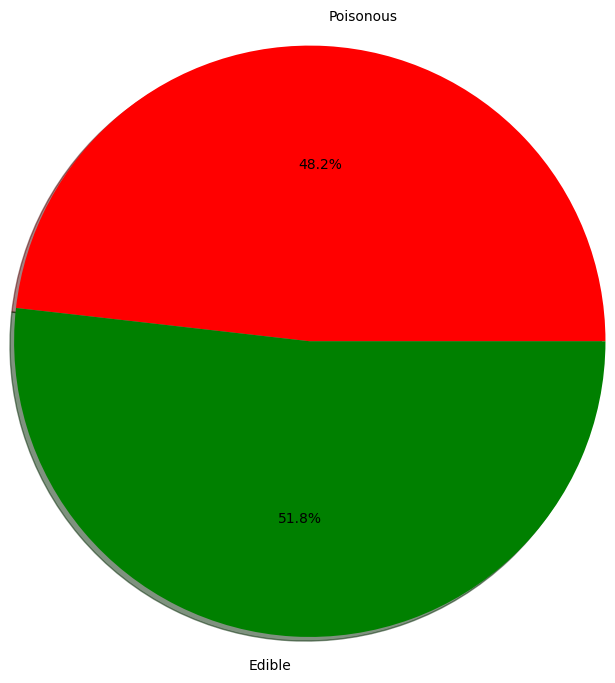

In [136]:
poisonous_count = len(data[data["class"] == "p"].index)  # Get poisonous count
edible_count = len(data[data["class"] == "e"].index)  # Get edible count

# Draw Pie Chart:
plt.pie([poisonous_count, edible_count], labels=["Poisonous", "Edible"], autopct='%1.1f%%', radius=2.0, shadow=True, colors=["r", "g"])
plt.show()

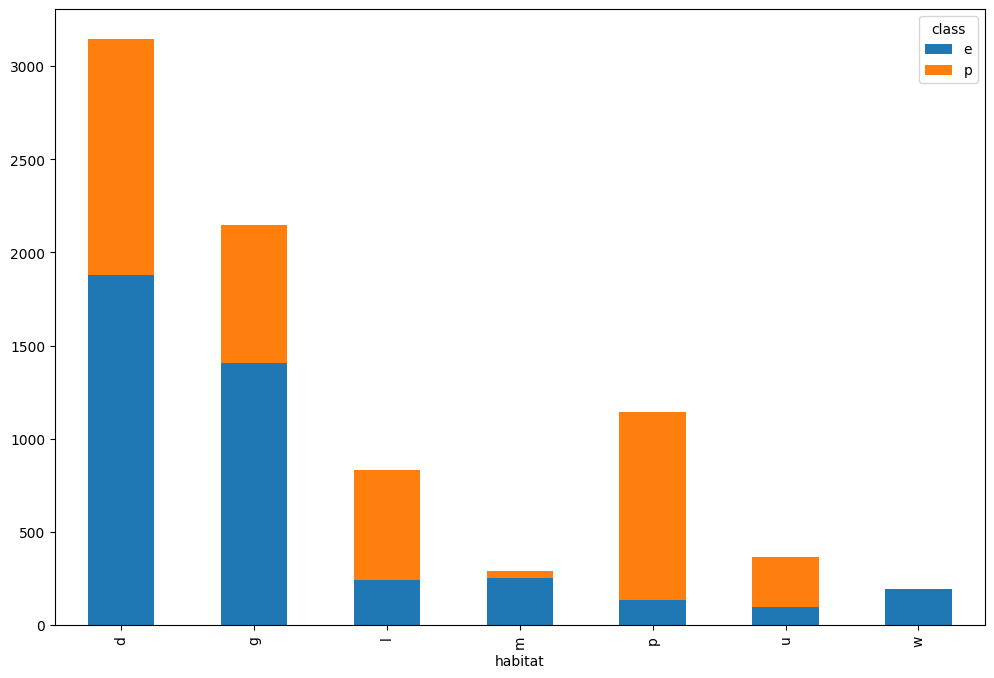

In [137]:
fig, ax = plt.subplots(figsize=(12,8))  # For specify figure size
data.groupby(['habitat', 'class']).size().unstack().plot.bar(stacked=True, ax=ax)  # Draw Stacked Bar Chart
plt.show()

# Data Cleaning

In [138]:
encoded_data.drop(["cap-shape", "veil-type"], axis=1, inplace=True)  # Drop "cap-shape" and "veil-type" columns from dataset
encoded_data.columns

Index(['class', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type',
       'spore-print-color', 'population', 'habitat'],
      dtype='str')

In [139]:
X = encoded_data.drop(["class"], axis=1)  # Put all data (except "class" column) to the X variable
y = encoded_data["class"] # Put only "class" column to the Y variable

In [140]:
X.head()

,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,2,4,1,6,1,0,1,4,0,3,2,2,7,7,2,1,4,2,3,5
1,2,9,1,0,1,0,0,4,0,2,2,2,7,7,2,1,4,3,2,1
2,2,8,1,3,1,0,0,5,0,2,2,2,7,7,2,1,4,3,2,3
3,3,8,1,6,1,0,1,5,0,3,2,2,7,7,2,1,4,2,3,5
4,2,3,0,5,1,1,0,4,1,3,2,2,7,7,2,1,0,3,0,1


In [141]:
y.head()

0    1
1    0
2    0
3    1
4    0
Name: class, dtype: int64

In [142]:
from sklearn.preprocessing import StandardScaler  # Import StandartScaler class
std_scaler = StandardScaler()  # Create instance for scaler

X = std_scaler.fit_transform(X)

In [143]:
from sklearn.decomposition import PCA  # Import class for PCA

for i in range(2, 20):
    pca = PCA(n_components=i)  # n_components = Specify the number of features you want to reduce.
    pca.fit_transform(X)
    print("Sum of Variance Ratio in " + str(i) + " Components: ", sum(pca.explained_variance_ratio_))

Sum of Variance Ratio in 2 Components:  0.3236994161261925
Sum of Variance Ratio in 3 Components:  0.4436975651811388
Sum of Variance Ratio in 4 Components:  0.5505658431443762
Sum of Variance Ratio in 5 Components:  0.6353141248749056
Sum of Variance Ratio in 6 Components:  0.7048916781851559
Sum of Variance Ratio in 7 Components:  0.752618585565471
Sum of Variance Ratio in 8 Components:  0.7915587881192003
Sum of Variance Ratio in 9 Components:  0.8272576534212522
Sum of Variance Ratio in 10 Components:  0.8561519396340413
Sum of Variance Ratio in 11 Components:  0.883273498018199
Sum of Variance Ratio in 12 Components:  0.908805217601762
Sum of Variance Ratio in 13 Components:  0.9328825325431445
Sum of Variance Ratio in 14 Components:  0.9521366964247959
Sum of Variance Ratio in 15 Components:  0.967699852654674
Sum of Variance Ratio in 16 Components:  0.9786466275158964
Sum of Variance Ratio in 17 Components:  0.9866489397663709
Sum of Variance Ratio in 18 Components:  0.993257207

In [144]:
pca = PCA(n_components=13)  # We will reduce the feature count to the 13
X = pca.fit_transform(X)  # Fit and transform with data

print(sum(pca.explained_variance_ratio_))  # Print variance ratio

0.9328825325431445


# Preparation of Test and Train Data

In [145]:
from sklearn.model_selection import train_test_split  # Import "train_test_split" method

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Parameters:
# test_size : It decides how many test data in percentage.
# random_state : This parameter can take any value. This value decides randomness seed.

# BUILDING MODELS

In [146]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1.Logistic Regression

In [147]:
logistic_regression_cls = LogisticRegression(random_state=13)  # Create instance for model
logistic_regression_cls.fit(x_train, y_train)  # Fit data with model

print("Train Score for Logistic Regression: ", logistic_regression_cls.score(x_train, y_train))  # Print Train Score
print("Test Score for Logistic Regression: ", logistic_regression_cls.score(x_test, y_test))  # Print Test Score

Train Score for Logistic Regression:  0.9130635482381905
Test Score for Logistic Regression:  0.9070769230769231


In [148]:
logistic_regression_cls.get_params()  # Print hyperparameters and their values for the model

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': 13,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

# 2,Gaussian Naive Bayes

In [149]:
naive_bayes_cls = GaussianNB()  # Create instance for model
naive_bayes_cls.fit(x_train, y_train)  # Fit data with model

print("Train Score for Gaussian Naive Bayes: ", naive_bayes_cls.score(x_train, y_train))  # Print Train Score
print("Test Score for Gaussian Naive Bayes: ", naive_bayes_cls.score(x_test, y_test))  # Print Test Score

Train Score for Gaussian Naive Bayes:  0.9296814894599169
Test Score for Gaussian Naive Bayes:  0.9187692307692308


In [150]:
naive_bayes_cls.get_params()

{'priors': None, 'var_smoothing': 1e-09}

# 3. Decision Tree

In [151]:
decision_tree_cls = DecisionTreeClassifier(random_state=13)  # Create instance for model
decision_tree_cls.fit(x_train, y_train)  # Fit data with model

print("Train Score for Decision Tree: ", decision_tree_cls.score(x_train, y_train))  # Print Train Score
print("Test Score for Decision Tree: ", decision_tree_cls.score(x_test, y_test))  # Print Test Score

Train Score for Decision Tree:  1.0
Test Score for Decision Tree:  0.9969230769230769


In [152]:
decision_tree_cls.get_params() 

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 13,
 'splitter': 'best'}

# 4. Random Forest

In [153]:
random_forest_cls = RandomForestClassifier(random_state=13)  # Create instance for model
random_forest_cls.fit(x_train, y_train)  # Fit data with model

print("Train Score for Random Forest: ", random_forest_cls.score(x_train, y_train))  # Print Train Score
print("Test Score for Random Forest: ", random_forest_cls.score(x_test, y_test))  # Print Test Score

Train Score for Random Forest:  1.0
Test Score for Random Forest:  1.0


In [154]:
random_forest_cls.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 13,
 'verbose': 0,
 'warm_start': False}

# Hyperparameter Tuning with Grid Search

In [155]:
# Specifying hyperparameters' range for the model:
parameters_LR = {"C" : [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                 "penalty" : ["l1", "l2"]}

# Create a Grid Search Cross Validation instance ("n_jobs=-1" means use all cores of the processor):
grid_search_LR = GridSearchCV(logistic_regression_cls, parameters_LR, cv=6, n_jobs=-1, return_train_score=True)

# Fit Grid Search model with data:
grid_search_LR.fit(x_train, y_train)

# Show results for all combinations:
pd.DataFrame(grid_search_LR.cv_results_)[["params", "mean_fit_time", "mean_train_score", "mean_test_score"]]

,params,mean_fit_time,mean_train_score,mean_test_score
0,"{'C': 0.001, 'penalty': 'l1'}",0.003471,NaN,NaN
1,"{'C': 0.001, 'penalty': 'l2'}",0.039179,0.897553,0.897523
2,"{'C': 0.01, 'penalty': 'l1'}",0.002687,NaN,NaN
3,"{'C': 0.01, 'penalty': 'l2'}",0.026617,0.911710,0.911679
4,"{'C': 0.1, 'penalty': 'l1'}",0.002829,NaN,NaN
5,"{'C': 0.1, 'penalty': 'l2'}",0.022944,0.913187,0.912911
6,"{'C': 1, 'penalty': 'l1'}",0.002800,NaN,NaN
7,"{'C': 1, 'penalty': 'l2'}",0.030287,0.913064,0.912757
8,"{'C': 10, 'penalty': 'l1'}",0.002728,NaN,NaN
9,"{'C': 10, 'penalty': 'l2'}",0.026695,0.913094,0.912603


In [156]:
grid_search_LR.best_params_  # Print best hyperparameters for the model

{'C': 0.1, 'penalty': 'l2'}

In [157]:
# Specifying hyperparameters' range for the model:
parameters_DT = {"max_depth" : np.arange(3, 20)}

# Create a Grid Search Cross Validation instance ("n_jobs=-1" means use all cores of the processor):
grid_search_DT = GridSearchCV(decision_tree_cls, parameters_DT, cv=6, n_jobs=-1, return_train_score=True)

# Fit Grid Search model with data:
grid_search_DT.fit(x_train, y_train)

# Show results for all combinations:
pd.DataFrame(grid_search_DT.cv_results_)[["params", "mean_fit_time", "mean_train_score", "mean_test_score"]]

,params,mean_fit_time,mean_train_score,mean_test_score
0,{'max_depth': 3},0.061669,0.895677,0.886903
1,{'max_depth': 4},0.086434,0.914325,0.906138
2,{'max_depth': 5},0.105991,0.943437,0.939066
3,{'max_depth': 6},0.114015,0.969072,0.966610
4,{'max_depth': 7},0.127369,0.981136,0.977535
5,{'max_depth': 8},0.142544,0.987691,0.985075
6,{'max_depth': 9},0.141953,0.992337,0.988767
7,{'max_depth': 10},0.156386,0.995999,0.991383
8,{'max_depth': 11},0.196404,0.998646,0.994922
9,{'max_depth': 12},0.215915,0.999261,0.996153


In [158]:
grid_search_DT.best_params_ 

{'max_depth': np.int64(14)}

In [159]:
# Logistic Regression Classifier:
logistic_regression_cls_tuned = LogisticRegression(C=0.1, penalty="l2", random_state=13)
logistic_regression_cls_tuned.fit(x_train, y_train)

# Gaussian Naive Bayes Classifier (Not Changed):
naive_bayes_cls_tuned = GaussianNB()
naive_bayes_cls_tuned.fit(x_train, y_train)

# Decision Tree Classifier:
decision_tree_cls_tuned = DecisionTreeClassifier(max_depth=14, random_state=13)
decision_tree_cls_tuned.fit(x_train, y_train)

# Random Forest Classifier:
random_forest_cls_tuned = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=13)
random_forest_cls_tuned.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [160]:
print("Test Score for Logistic Regression: ", logistic_regression_cls_tuned.score(x_test, y_test))
print("Test Score for Gaussian Naive Bayes: ", naive_bayes_cls_tuned.score(x_test, y_test))
print("Test Score for Decision Tree: ", decision_tree_cls_tuned.score(x_test, y_test))
print("Test Score for Random Forest: ", random_forest_cls_tuned.score(x_test, y_test))

Test Score for Logistic Regression:  0.9083076923076923
Test Score for Gaussian Naive Bayes:  0.9187692307692308
Test Score for Decision Tree:  0.9969230769230769
Test Score for Random Forest:  1.0


# Evaluating Models

In [161]:
from sklearn.metrics import confusion_matrix  # For find confusion matrix
from sklearn.metrics import classification_report  # For print evaluation report
from sklearn.metrics import roc_curve  # For drawing ROC curve
from sklearn.metrics import auc  # For find AUC

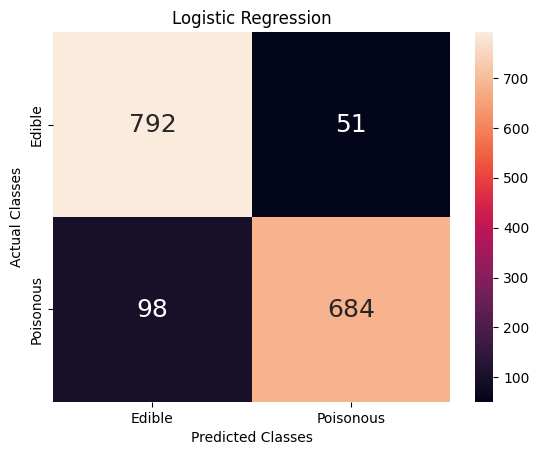

In [162]:
# Prediction of test dataset:
y_pred_LR = logistic_regression_cls_tuned.predict(x_test)

# Find confusion matrix for this model:
confusion_matrix_LR = confusion_matrix(y_test, y_pred_LR)

# Plot confusion matrix with Heatmap:
cm_dataframe_LR = pd.DataFrame(confusion_matrix_LR, index=["Edible", "Poisonous"], columns=["Edible", "Poisonous"])
sns.heatmap(cm_dataframe_LR, annot=True, annot_kws={"size": 18}, fmt="d")
plt.title("Logistic Regression")
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show()

In [163]:
report_LR = pd.DataFrame(classification_report(y_test, y_pred_LR, 
                                               output_dict=True, 
                                               target_names=["Edible", "Poisonous"]))
report_LR

,Edible,Poisonous,accuracy,macro avg,weighted avg
precision,0.889888,0.930612,0.908308,0.910250,0.909486
recall,0.939502,0.874680,0.908308,0.907091,0.908308
f1-score,0.914022,0.901780,0.908308,0.907901,0.908131
support,843.000000,782.000000,0.908308,1625.000000,1625.000000


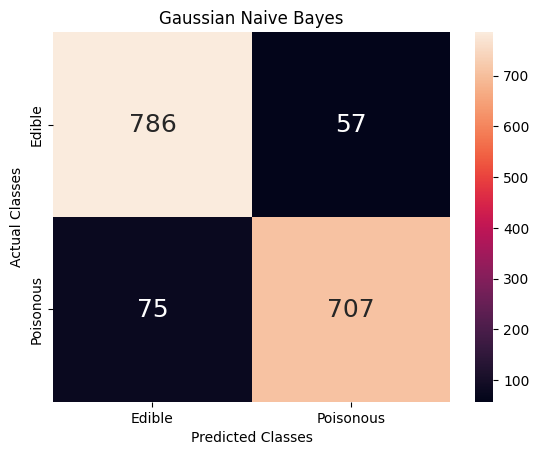

In [164]:
# Prediction of test dataset:
y_pred_GNB = naive_bayes_cls_tuned.predict(x_test)

# Find confusion matrix for this model:
confusion_matrix_GNB = confusion_matrix(y_test, y_pred_GNB)

# Plot confusion matrix with Heatmap:
cm_dataframe_GNB = pd.DataFrame(confusion_matrix_GNB, index=["Edible", "Poisonous"], columns=["Edible", "Poisonous"])
sns.heatmap(cm_dataframe_GNB, annot=True, annot_kws={"size": 18}, fmt="d")
plt.title("Gaussian Naive Bayes")
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show()

In [165]:
report_GNB = pd.DataFrame(classification_report(y_test, y_pred_GNB, 
                                                output_dict=True, 
                                                target_names=["Edible", "Poisonous"]))
report_GNB

,Edible,Poisonous,accuracy,macro avg,weighted avg
precision,0.912892,0.925393,0.918769,0.919142,0.918908
recall,0.932384,0.904092,0.918769,0.918238,0.918769
f1-score,0.922535,0.914618,0.918769,0.918577,0.918725
support,843.000000,782.000000,0.918769,1625.000000,1625.000000


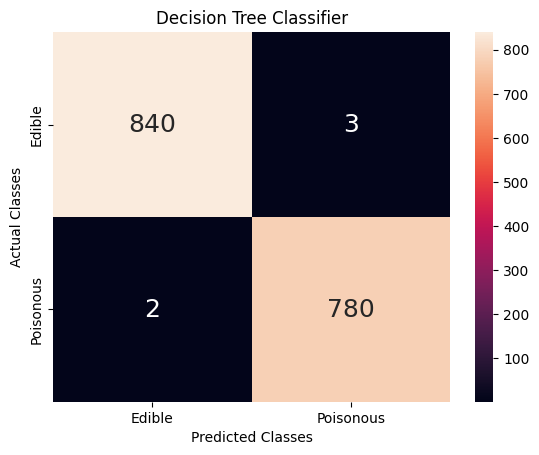

In [166]:
# Prediction of test dataset:
y_pred_DT = decision_tree_cls_tuned.predict(x_test)

# Find confusion matrix for this model:
confusion_matrix_DT = confusion_matrix(y_test, y_pred_DT)

# Plot confusion matrix with Heatmap:
cm_dataframe_DT = pd.DataFrame(confusion_matrix_DT, index=["Edible", "Poisonous"], columns=["Edible", "Poisonous"])
sns.heatmap(cm_dataframe_DT, annot=True, annot_kws={"size": 18}, fmt="d")
plt.title("Decision Tree Classifier")
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show()

In [167]:
report_DT = pd.DataFrame(classification_report(y_test, y_pred_DT, 
                                               output_dict=True, 
                                               target_names=["Edible", "Poisonous"]))
report_DT

,Edible,Poisonous,accuracy,macro avg,weighted avg
precision,0.997625,0.996169,0.996923,0.996897,0.996924
recall,0.996441,0.997442,0.996923,0.996942,0.996923
f1-score,0.997033,0.996805,0.996923,0.996919,0.996923
support,843.000000,782.000000,0.996923,1625.000000,1625.000000


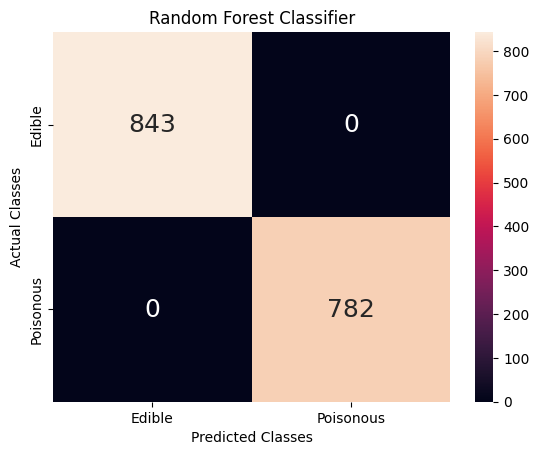

In [168]:
# Prediction of test dataset:
y_pred_RF = random_forest_cls_tuned.predict(x_test)

# Find confusion matrix for this model:
confusion_matrix_RF = confusion_matrix(y_test, y_pred_RF)

# Plot confusion matrix with Heatmap:
cm_dataframe_RF = pd.DataFrame(confusion_matrix_RF, index=["Edible", "Poisonous"], columns=["Edible", "Poisonous"])
sns.heatmap(cm_dataframe_RF, annot=True, annot_kws={"size": 18}, fmt="d")
plt.title("Random Forest Classifier")
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.show()

In [169]:
report_RF = pd.DataFrame(classification_report(y_test, y_pred_RF, 
                                               output_dict=True, 
                                               target_names=["Edible", "Poisonous"]))
report_RF

,Edible,Poisonous,accuracy,macro avg,weighted avg
precision,1.0,1.0,1.0,1.0,1.0
recall,1.0,1.0,1.0,1.0,1.0
f1-score,1.0,1.0,1.0,1.0,1.0
support,843.0,782.0,1.0,1625.0,1625.0


# EXPLORATION OF RESULTS

In [170]:
# Create list that keep model names:
model_names = ["Logistic Regression", 
               "Gaussian Naive Bayes",
               "Decision Tree Classification",
               "Random Forest Classification"]

# Shortening models' variables names for quick usage:
LR_model = logistic_regression_cls_tuned
GNB_model = naive_bayes_cls_tuned
DT_model = decision_tree_cls_tuned
RF_model = random_forest_cls_tuned

# Get model hyperparameters into variables:
LR_model_C = str(LR_model.get_params()["C"])
LR_model_penalty = str(LR_model.get_params()["penalty"])
DT_mode_max_depth = str(DT_model.get_params()["max_depth"])
RF_model_n_estimators = str(RF_model.get_params()["n_estimators"])
RF_model_max_depth = str(RF_model.get_params()["max_depth"])

# Create list that keep models' training accuracies:
model_training_accuracies = [LR_model.score(x_train, y_train),
                             GNB_model.score(x_train, y_train),
                             DT_model.score(x_train, y_train),
                             RF_model.score(x_train, y_train)]

# Create list that keep models' testing accuracies:
model_testing_accuracies = [LR_model.score(x_test, y_test),
                             GNB_model.score(x_test, y_test),
                             DT_model.score(x_test, y_test),
                             RF_model.score(x_test, y_test)]

# Create list that keep models' F1 scores:
model_f1_scores = [report_LR.iloc[0]["weighted avg"],
                   report_GNB.iloc[0]["weighted avg"],
                   report_DT.iloc[0]["weighted avg"],
                   report_RF.iloc[0]["weighted avg"]]

# Create list that keep models' precisions:
model_precisions = [report_LR.iloc[1]["weighted avg"],
                   report_GNB.iloc[1]["weighted avg"],
                   report_DT.iloc[1]["weighted avg"],
                   report_RF.iloc[1]["weighted avg"]]

# Create list that keep models' recalls:
model_recalls = [report_LR.iloc[2]["weighted avg"],
                report_GNB.iloc[2]["weighted avg"],
                report_DT.iloc[2]["weighted avg"],
                report_RF.iloc[2]["weighted avg"]]

# Generate table data with column names:
table_data = { "Training Accuracy" : model_training_accuracies,
              "Testing Accuracy" : model_testing_accuracies,
              "F1 Score" : model_f1_scores,
              "Precision" : model_precisions,
              "Recall" : model_recalls}

# Create and print result table:
table_dataframe = pd.DataFrame(data=table_data, index=model_names)
table_dataframe

,Training Accuracy,Testing Accuracy,F1 Score,Precision,Recall
Logistic Regression,0.913217,0.908308,0.909486,0.908308,0.908131
Gaussian Naive Bayes,0.929681,0.918769,0.918908,0.918769,0.918725
Decision Tree Classification,1.000000,0.996923,0.996924,0.996923,0.996923
Random Forest Classification,1.000000,1.000000,1.000000,1.000000,1.000000


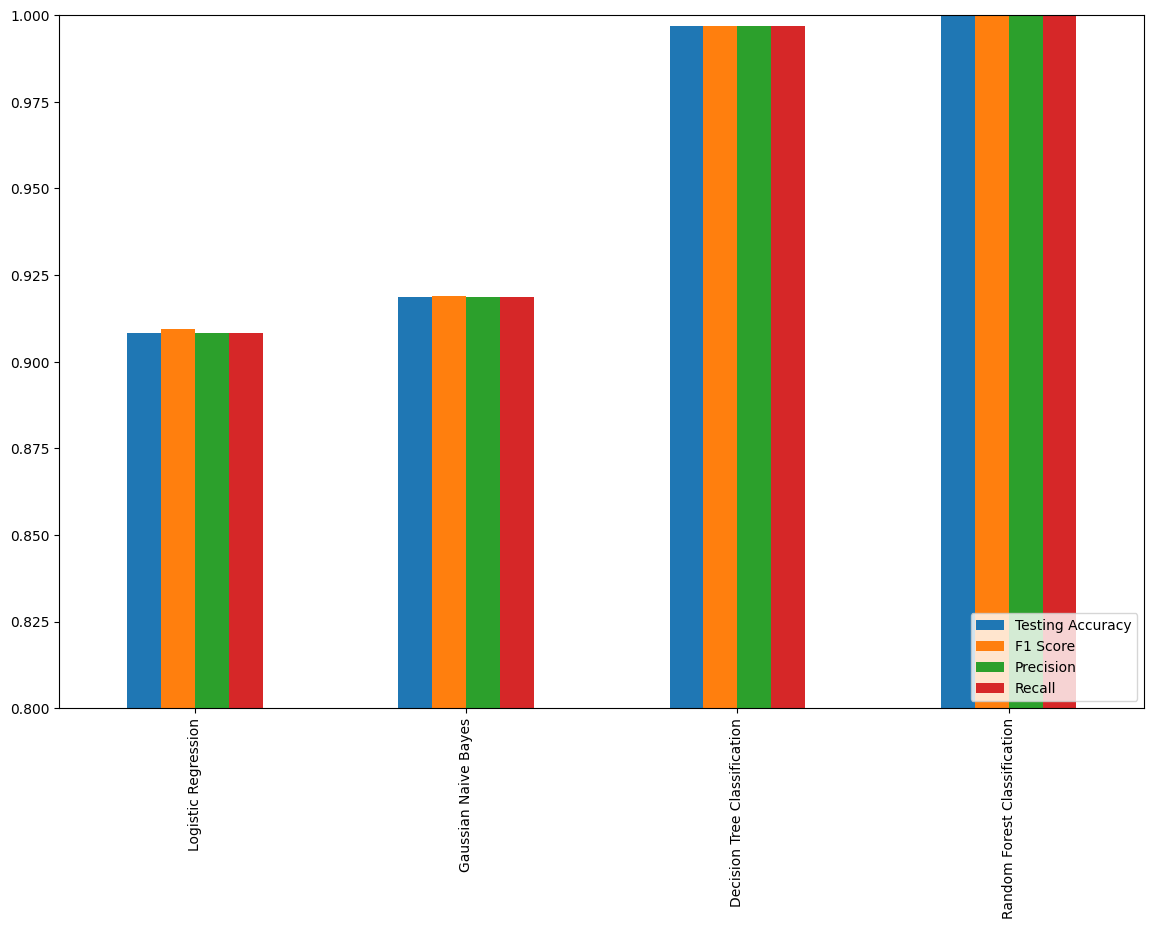

In [171]:
table_dataframe.iloc[:, 1:].plot(kind="bar", ylim=[0.8, 1.0], figsize=(14, 9)) # Y Limit: 0.8 - 1.0
plt.legend(loc='lower right')
plt.show()